# TC Track Diagnostics - Lead-Time Diagnostics

Focused notebook for single- and multi-E3SM lead-time track-density comparisons, IBTrACS companion analysis, and ENSO regression diagnostics.


In [1]:
import os
import sys
from pathlib import Path
from esp_lab.utils.dask_util import DaskConfig, get_cluster_client
from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources
import numpy as np
import re

import subprocess
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
from esp_lab.utils import mov_utils as mov

# Python interpreter for the tracking script.
# When the kernel IS e3sm_analysis, sys.executable is already correct.
PYTHON = sys.executable
print(f"PYTHON      : {PYTHON}")
print(f"CONDA_PREFIX: {os.environ.get('CONDA_PREFIX', '(not set — fallback paths used)')}")

_repo_override = os.environ.get("ESP_LAB_REPO_ROOT")
_repo_candidates = ([Path(_repo_override).expanduser().resolve()] if _repo_override
                    else [Path.cwd().resolve(), *Path.cwd().resolve().parents])
REPO_ROOT = next((p for p in _repo_candidates
                  if (p / "scripts" / "run_process_tc_track_e3sm.py").is_file()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Start Jupyter inside ESP-Lab or set ESP_LAB_REPO_ROOT to its checkout.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# PROJ data path — auto-resolved when running under the e3sm_analysis kernel
# (CONDA_PREFIX is set).  Hardcoded fallback only needed if kernel is not activated.
_proj_path = os.path.join(os.environ.get("CONDA_PREFIX", ""), "share", "proj")
os.environ["PROJ_LIB"]  = _proj_path
os.environ["PROJ_DATA"] = _proj_path

PYTHON      : /global/homes/z/zhan391/.conda/envs/e3sm_analysis/bin/python
CONDA_PREFIX: /global/homes/z/zhan391/.conda/envs/e3sm_analysis


## Configuration — fill in ALL fields before running

Fields left as `None` will cause the **Validate** cell to raise an error. All processing, observational, plotting, regression, and statistics controls are collected here so later sections contain only analysis logic.

In [ ]:
# Optional common processing end year. None uses 2018.
YEAR_END = 2011  # None

years  = 1980
yeare  = 2018 if YEAR_END is None else int(YEAR_END)
yexcl  = None          # set to a year int to exclude, or None

init_months = [5, 11]  # May and November starts

lead_years = [y for y in np.arange(years, yeare + 1) if y != yexcl]

# ------------------------------------------------------------------ #
#  ENSEMBLE / PARSET
# ------------------------------------------------------------------ #
case_nens = 10
members   = [f"EN{i:02d}" for i in range(case_nens)]
MEMBERS   = members
NENS      = None   # e.g. 3 for a quick test
PARSET    = "set3"

# Replace existing diagnostics NetCDF files when rerunning with a new method/setup.
OVERWRITE_OUTPUT = True

# TempestExtremes products, ensured below from raw history files when missing.
TRACK_DIR    = Path("/global/cfs/cdirs/e3sm/S2S2D/post_process")

# Local helper modules used by this diagnostics notebook.
WORKFLOWS_DIR  = REPO_ROOT / "workflows"

# ------------------------------------------------------------------ #
#  PATHS
# ------------------------------------------------------------------ #
S2D_DIAG_ROOT = Path("/global/cfs/cdirs/e3sm/S2S2D/s2d_diag")
E3SMLE_DIAG_DIR = S2D_DIAG_ROOT
HADISST2_DIAG_DIR = S2D_DIAG_ROOT / "HadISST2"
CESM_SMYLE_DIAG_DIR = S2D_DIAG_ROOT / "CESM-SMYLE"
NMME_DIAG_DIR = S2D_DIAG_ROOT / "NMME"
MODES_VARIABILITY_DIAG_DIR = S2D_DIAG_ROOT

# Niño-3.4 regression inputs
# ---- Configure Niño index input ----
# Provide a monthly Niño-3.4 index file when possible. The regression uses
# Niño-3.4 averaged over the corresponding TC season:
#   NH_JJASON: June-November of year Y
#   SH_DJFMAM: December of year Y through May of year Y+1
# If the input is already yearly, the same yearly index is used for both seasons.
# Use the existing HadISST2 regional-mean SST series. The loader below
# converts it to monthly anomalies before forming the seasonal index.
NINO_FILE = HADISST2_DIAG_DIR / "sst_index" / "timeseries" / "HadISST2_sst_Nino3.4SST_mon.nc"
NINO_VAR = "sst"
NINO_CLIM_YEARS = (1981, 2010)
REG_NINO_LABEL = "hadisst2"


# Regression significance
SIG_CONFIDENCE = 0.90
SIG_ALPHA = 1.0 - SIG_CONFIDENCE

# ------------------------------------------------------------------ #
#  CASES
# ------------------------------------------------------------------ #

E3SM_HINDCASTS = {
    "JRA55_FOSIRL": {
        "sim_dir": "/global/cfs/cdirs/e3smdata/simulations/S2S2D",
        "stream_tag": "eam.h2",
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL",
        "label": "E3SMv3-FOSIRL",
        "color": "black",
        "marker": "o",
        "enabled": True,
    },
    "Reanalysis": {
        "sim_dir": "/global/cfs/cdirs/e3sm/S2S2D/simulation",
        "stream_tag": "eam.h3",
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce",
        "label": "E3SMv3-Reanalysis",
        "color": "tab:blue",
        "marker": "s",
        "enabled": True,
    },
    "4DEnVarOcn": {
        "sim_dir": "/global/cfs/cdirs/e3sm/S2S2D/simulation",
        "stream_tag": "eam.h3",
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn",
        "label": "E3SMv3-4DEnVarOcn",
        "color": "tab:purple",
        "marker": "^",
        "enabled": True,
    },
}


# ENSO regression comparison figure: include every enabled experiment that
# supports the selected TempestExtremes parameter set.
REGRESSION_CASE_KEYS = [
    key for key, spec in E3SM_HINDCASTS.items()
    if spec.get("enabled", True) and PARSET in spec.get("tc_parsets", [PARSET])
]

# -----------------------------------------------------------------------------
# Directory setup
# -----------------------------------------------------------------------------
# Override the root for a different workspace with ESP_LAB_S2D_DIAG_ROOT.
DIAG_ROOT = S2D_DIAG_ROOT
E3SMLE_OUTDIR = E3SMLE_DIAG_DIR
CESM_SMYLE_OUTDIR = CESM_SMYLE_DIAG_DIR
SMYLE_BENCHMARK_DIR = str(CESM_SMYLE_OUTDIR)
NMME_OUTDIR = NMME_DIAG_DIR
MODES_OUTDIR = MODES_VARIABILITY_DIAG_DIR

# Backward-compatible interactive case used by the detailed cells below.
# Missing exact-period caches for all configured experiments are built
# automatically before multi-experiment analysis, so this does not need
# to be changed manually between experiments.
PROCESS_CASE_KEY = "Reanalysis"
if PROCESS_CASE_KEY not in E3SM_HINDCASTS:
    raise KeyError(f"Unknown PROCESS_CASE_KEY={PROCESS_CASE_KEY!r}")
ACTIVE_CASE = E3SM_HINDCASTS[PROCESS_CASE_KEY]
case_prefix = ACTIVE_CASE["case_prefix"]
OUTDIR = E3SMLE_OUTDIR / PROCESS_CASE_KEY / "tc_track"

CASES = [
    f"{case_prefix}_{year}{init_month:02d}0100"
    for init_month in init_months
    for year in lead_years
]

print(f"Total cases: {len(CASES)}")
print("First few:", CASES[:3])
print("Last few: ", CASES[-3:])


# Default figure output directory for this HPC environment.
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

TABLE_OUTDIR = Path(S2D_DIAG_ROOT / "multimodel" / "tropical_cyclones" / "tables")
TABLE_OUTDIR.mkdir(parents=True, exist_ok=True)

MULTI_E3SM_STATISTICS_CONFIG = {
    "case_keys": [
        key for key, spec in E3SM_HINDCASTS.items()
        if spec["enabled"] and PARSET in spec.get("tc_parsets", [PARSET])
    ],
    "required_seasons": ["NH_JJASON", "SH_DJFMAM"],
}
PROCESS_CASE_KEYS = list(MULTI_E3SM_STATISTICS_CONFIG["case_keys"])


# ============================================================================
# Centralized diagnostic and plotting controls
# ============================================================================

# Track-density processing
LEADS = np.array([1, 4, 7, 10, 13, 16, 19], dtype=int)

# Diagnostic track-density grid and definition.
DIAG_GRID_SIZE = 5.0

# Use "box" to reproduce the original S2D/SMYLE 5-degree grid-box workflow.
# Use "radius" only as a separate smooth unique-track diagnostic.
TRACK_DENSITY_METHOD = "box"  # "box" reproduces Yeager et al.; "radius" is a separate sensitivity diagnostic
TRACK_DENSITY_RADIUS_KM = 350.0  # used only when TRACK_DENSITY_METHOD == "radius"
TRACK_DENSITY_EARTH_RADIUS_KM = 6370.0

# Model-track filtering
POINT_WIND_MIN = None  # m/s; set only for sensitivity tests

# IBTrACS companion processing
IBTRACS_FILE = Path(
    "/global/cfs/cdirs/e3sm/S2S2D/"
    "IBTrACS/IBTrACS.since1980.v04r00.nc"
)

# Observations need an intensity threshold; model tracks are already filtered
# during the TempestExtremes tracking stage.
OBS_WIND_MIN_KT = 35.0  # Yeager NCL uses wind >= 18 m/s, approximately 35 kt

# Match the 6-hourly E3SM track output: 00/06/12/18 UTC.
OBS_TIME_STEP_HOURS = 6


# Basin masks used for integrated statistics
BASIN_DEFS = {
    # TC-community basin masks on the 0-360 degrees-east grid.
    # Based on IBTrACS/WMO basin longitudes where they are longitude-defined.
    # EP and NA are coastline-aware in IBTrACS; these are rectangular
    # longitude approximations for gridded diagnostics.
    "NWP": {"season": "NH_JJASON", "lon": (100, 180), "lat": (0, 40), "long_name": "Northwestern Pacific"},
    "NA":  {"season": "NH_JJASON", "lon": (260, 360), "lat": (0, 40), "long_name": "North Atlantic"},
    "EP":  {"season": "NH_JJASON", "lon": (180, 260), "lat": (0, 40), "long_name": "Eastern Pacific"},
    "NI":  {"season": "NH_JJASON", "lon": (30, 100),  "lat": (0, 40), "long_name": "North Indian Ocean"},
    "SI":  {"season": "SH_DJFMAM", "lon": (10, 135), "lat": (-40, 0), "long_name": "South Indian Ocean"},
    "SP":  {"season": "SH_DJFMAM", "lon": (135, 290), "lat": (-40, 0), "long_name": "South Pacific Ocean"},
}


# Annual track-density map figure
# ============================================================
# User-controlled setup parameters
# ============================================================

# Years
REQUESTED_YEARS = np.asarray(
    [y for y in range(years, yeare + 1) if yexcl is None or y != yexcl],
    dtype=int,
)

# Seasons and lead
REQUIRED_SEASONS = ["NH_JJASON", "SH_DJFMAM"]
PLOT_LEAD = 1

# Compared E3SM cases and plot labels
PRIMARY_CASE_KEY = "JRA55_FOSIRL"
REFERENCE_CASE_KEY = "Reanalysis"
MODEL_LABEL = E3SM_HINDCASTS[PRIMARY_CASE_KEY]["label"]
REFERENCE_LABEL = E3SM_HINDCASTS[REFERENCE_CASE_KEY]["label"]
OBS_LABEL = "Best Track"
SHOW_BASIN_TOTALS = True
INCLUDE_SOUTH_ATLANTIC_BASINS = False
DENSITY_LABEL = (
    f"6-hourly TC track locations per "
    f"{DIAG_GRID_SIZE:g}°×{DIAG_GRID_SIZE:g}° box per year"
    if TRACK_DENSITY_METHOD == "box"
    else f"unique TC tracks within {TRACK_DENSITY_RADIUS_KM:g} km per year"
)

# Map/domain setup
MAP_EXTENT = [0, 360, -70, 70]
CENTRAL_LONGITUDE = 180
FIGSIZE = (8.8, 16.2)
PLOT_NROWS = 1 + len(E3SM_HINDCASTS)
PLOT_NCOLS = 1
SUBPLOT_ADJUST = dict(left=0.08, right=0.98, top=0.96, bottom=0.07, hspace=0.28)
COLORBAR_AX_POSITION = [0.10, 0.025, 0.85, 0.012]  # [left, bottom, width, height]

# Axis ticks
XTICKS = np.arange(0, 361, 60)
XTICK_LABELS = ["0", "60°E", "120°E", "180", "120°W", "60°W", "0"]
YTICKS = [-60, -30, 0, 30, 60]
YTICK_LABELS = ["60°S", "30°S", "0", "30°N", "60°N"]

# Font-size setup
FONTZ = 18
TITLE_FONTSIZE = 1.0 * FONTZ
PANEL_LABEL_FONTSIZE = 0.95 * FONTZ
TICK_FONTSIZE = 0.90 * FONTZ
COLORBAR_TITLE_FONTSIZE = 0.95 * FONTZ
COLORBAR_TICK_FONTSIZE = 0.90 * FONTZ

# Colorbar setup
COLORBAR_BOUNDS = [
    0.0, 0.01, 0.2, 0.5, 1.0, 1.5, 2.0,
    2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0
]

COLORBAR_TICKS = [0.01, 0.2, 1, 2, 3, 4, 5]
COLORBAR_TICK_LABELS = ["0.01", "0.2", "1", "2", "3", "4", "5"]

COLORBAR_COLORS = [
    "white",
    "#b8b8ff",
    "#5f63ff",
    "#1b1bff",
    "#123ac8",
    "#0b6a7c",
    "#0a9b36",
    "#28c20e",
    "#7be000",
    "#d4f000",
    "#fff000",
    "#ff9f00",
    "#ff4a00",
]

MIN_PLOT_VALUE = 0.01

# Basin boxes from Knutson et al. (2020, BAMS), using 0-360 longitude convention.
MAIN_BASINS = {
    "NA":  {"lon1": 265, "lon2": 360, "lat1": 0,   "lat2": 90, "text_xy": (312, 51)},
    "NEP": {"lon1": 180, "lon2": 265, "lat1": 0,   "lat2": 90, "text_xy": (222, 51)},
    "NWP": {"lon1": 100, "lon2": 180, "lat1": 0,   "lat2": 90, "text_xy": (140, 51)},
    "NI":  {"lon1": 30,  "lon2": 100, "lat1": 0,   "lat2": 90, "text_xy": (65, 51)},
    "SI":  {"lon1": 20,  "lon2": 135, "lat1": -90, "lat2": 0,  "text_xy": (78, -51)},
    "SWP": {"lon1": 135, "lon2": 295, "lat1": -90, "lat2": 0,  "text_xy": (215, -51)},
}

OPTIONAL_BASINS = {
    "SA1": {"lon1": 295, "lon2": 360, "lat1": -90, "lat2": 0,  "text_xy": (328, -35)},
    "SA2": {"lon1": 0,   "lon2": 20,  "lat1": 0,   "lat2": 90, "text_xy": (10, 51)},
}

BASINS = MAIN_BASINS.copy()
if INCLUDE_SOUTH_ATLANTIC_BASINS:
    BASINS.update(OPTIONAL_BASINS)

# Styling
COASTLINE_WIDTH = 0.8
SPINE_WIDTH = 1.0
TICK_LENGTH = 5
TICK_WIDTH = 1.0
TITLE_PAD = 8
COLORBAR_TITLE_PAD = 10
COLORBAR_OUTLINE_WIDTH = 1.0
COLORBAR_DIVIDER_WIDTH = 0.9
BASIN_BOX_WIDTH = 0.9
BASIN_LABEL_FONTSIZE = 0.90 * FONTZ
PANEL_LABEL_XY = (0.02, 0.86)
PANEL_LABEL_BBOX = dict(
    boxstyle="round,pad=0.2",
    facecolor="white",
    edgecolor="lightgray",
    alpha=0.85,
    linewidth=0.8,
)

# ============================================================
# User-controlled setup parameters
# ============================================================

# Lead selection and data display
PLOT_LEADS_REQUESTED = [1, 7, 13, 19]
PLOT_SIGNIFICANT_ONLY = False
PLOT_SIGNIFICANCE_MARKERS = True
PLOT_MARKER_STRIDE = 1

# Color scaling
COLOR_LIMIT_MODE = "yeager"  # "model_auto" reveals weak E3SM slopes; use "yeager" for +/-2.2.
COLOR_LIMIT = 1.0
COLOR_LIMIT_MIN = 0.2
COLOR_LIMIT_PERCENTILE = 99.0
N_COLOR_INTERVALS = 22
N_COLORBAR_TICKS = 9
COLORMAP_NAME = "RdYlBu_r"

# Figure layout: BestTrack is centered on top; one column per enabled E3SM
# experiment is shown below for each requested lead.
FIGSIZE_REGRESSION = (14, 12)
GRID_NROWS = 1 + len(PLOT_LEADS_REQUESTED)
GRID_NCOLS = len(REGRESSION_CASE_KEYS)
OBS_GRID_SLOT = (0, GRID_NCOLS // 2)
REGRESSION_SUBPLOT_ADJUST = dict(
    left=0.04, right=0.995, 
    top=0.965, bottom=0.14, 
    hspace=0.48, wspace=0.28
    )

# Map/domain setup
MAP_EXTENT_REGRESSION = [0, 360, -50, 50]
CENTRAL_LONGITUDE_REGRESSION = 180
XTICKS_REGRESSION = np.arange(0, 361, 60)
YTICKS_REGRESSION = [-40, -20, 0, 20, 40]
SHOW_EQUATOR_LINE = False
EQUATOR_LINE_WIDTH = 1.0
COASTLINE_WIDTH_REGRESSION = 0.45
SPINE_WIDTH_REGRESSION = 1.0
TICK_LENGTH_REGRESSION = 3.2
TICK_WIDTH_REGRESSION = 0.8

# Font and annotation setup
FONTZ_REGRESSION = 18
TITLE_FONTSIZE_REGRESSION = 1.00 * FONTZ_REGRESSION
TITLE_PAD_REGRESSION = 8
TICK_FONTSIZE_REGRESSION = 0.90 * FONTZ_REGRESSION
PANEL_LABEL_FONTSIZE_REGRESSION = 0.95 * FONTZ_REGRESSION
PANEL_LABEL_XY_REGRESSION = (0.012, 0.82)
PANEL_LABEL_BBOX_REGRESSION = dict(
    boxstyle="round,pad=0.2",
    facecolor="white",
    edgecolor="lightgray",
    alpha=0.85,
    linewidth=0.8,
)
NO_SAMPLE_FONTSIZE = 1.00 * FONTZ_REGRESSION

# Significance marker setup
SIG_MARKER_SIZE = 10.0
SIG_MARKER_STYLE = "."
SIG_MARKER_COLOR = "black"
SIG_MARKER_ALPHA = 0.90
SIG_MARKER_LINEWIDTH = 0.0

# Basin-box setup for the BestTrack panel
BASIN_BOX_LINEWIDTH_REGRESSION = 1.5
BASIN_BOX_COLOR_REGRESSION = "#4b751f"
BASIN_LABEL_FONTSIZE_REGRESSION = 1.00 * FONTZ_REGRESSION
BASIN_LABEL_COLOR_REGRESSION = "#565454"
BASIN_LABEL_LON_PAD_REGRESSION = 3.0
BASIN_LABEL_LAT_PAD_REGRESSION = 3.0
BASIN_LABEL_BBOX_REGRESSION = dict(
    boxstyle="round,pad=0.12",
    facecolor="white",
    edgecolor="none",
    alpha=0.2,
)

# Colorbar and footnote setup
COLORBAR_PAD_REGRESSION = 0.045
COLORBAR_SHRINK_REGRESSION = 0.84
COLORBAR_ASPECT_REGRESSION = 56
COLORBAR_FRACTION_REGRESSION = 0.030
COLORBAR_AX_POSITION_REGRESSION = [0.18, 0.045, 0.64, 0.018]
COLORBAR_TICK_FONTSIZE_REGRESSION = 0.90 * FONTZ_REGRESSION
COLORBAR_LABEL_FONTSIZE_REGRESSION = 0.95 * FONTZ_REGRESSION
# Basin boxes for the observational regression panel
REGRESSION_BASINS = {
    "NI":  {"lon1": 30,  "lon2": 100, "lat1": 0,   "lat2": 25, "text_xy": (37, 14)},
    "NWP": {"lon1": 100, "lon2": 180, "lat1": 0,   "lat2": 45, "text_xy": (130, 34)},
    "EP":  {"lon1": 180, "lon2": 260, "lat1": 0,   "lat2": 45, "text_xy": (215, 34)},
    "NA":  {"lon1": 260, "lon2": 360, "lat1": 0,   "lat2": 45, "text_xy": (320, 12)},
    "SI":  {"lon1": 30,  "lon2": 135, "lat1": -40, "lat2": 0,  "text_xy": (37, -16)},
    "SP":  {"lon1": 135, "lon2": 290, "lat1": -40, "lat2": 0,  "text_xy": (250, -12)},
}

SIMULATION_DIR = Path(ACTIVE_CASE["sim_dir"])
HISTORY_STREAM = ACTIVE_CASE["stream_tag"]
TC_PARSETS = [PARSET]

# Input policy: auto builds missing/stale tracks, require validates only,
# rebuild regenerates the requested tracking products.
TC_INPUT_MODE = "auto"
# Exact-period diagnostic policy: auto builds only missing caches, require
# validates without building, and rebuild replaces every configured cache.
TC_DIAGNOSTIC_MODE = "auto"
DASK_SETTINGS = {
    "enabled": True,
    "cluster_type": os.environ.get("CLUSTER_TYPE", "local"),
    "workers": 4,
    "cores": 1,
    "memory_limit": "4GB",
}
TC_TRACK_SETTINGS = {
    "sim_dir": SIMULATION_DIR,
    "stream_tag": HISTORY_STREAM,
    "phis_stream_tag": "eam.h0",
    "grid": "ne30pg2",
    "connect_file": "/global/cfs/cdirs/e3sm/zhan391/TempestExtremes/grid_info/outCS_ne30pg2_connect.txt",
    "te_bin": os.environ.get("ESP_LAB_TE_BIN", str(Path(sys.executable).parent)),
    "nco_bin": os.environ.get("ESP_LAB_NCO_BIN", str(Path(sys.executable).parent)),
    "workers": 10,
    "psl_fo_mag": 200.0, "psl_fo_dist": 8.0,
    "wc_fo_dist": 8.0, "wc_max_offset": 3.0, "merge_dist": 6.0,
    "traj_range": 10.0, "traj_min_length": "10", "traj_max_gap": "3",
    "max_topo": 150.0, "max_lat": 50.0, "min_wind": 8.0, "sci_dist": 9,
    "warm_core_overrides": {},  # Default set1–set5 fields/thresholds match 0_run_tc_track_diag.
}


Total cases: 64
First few: ['WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_1980050100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_1981050100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_1982050100']
Last few:  ['WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_2009110100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_2010110100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_2011110100']


## Ensure and validate tracking inputs

This calls the TC processor directly; running `preprocessing/tc/0_run_tc_track_diag.ipynb` first is optional.
Raw simulation history and TempestExtremes/NCO are required only when products need building.

`TC_INPUT_MODE="auto"` reuses complete track/histogram pairs and builds missing products.
`"require"` validates without processing; `"rebuild"` reruns tracking. New products record their tracking settings; complete legacy products are reused with a provenance notice.
IBTrACS remains an external observational input. Diagnostic calculations and figures run after input preparation.
Before comparison, the notebook loops over `PROCESS_CASE_KEYS`. In `auto` mode it reuses each exact `{years}_{yeare}` cache and processes only missing experiments; `require` validates only and `rebuild` replaces them. The ENSO cell can build the default HadISST2 Niño-3.4 index directly.


In [3]:
import subprocess
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

_required = {
    "PROCESS_CASE_KEYS": PROCESS_CASE_KEYS,
    "TRACK_DIR": TRACK_DIR,
    "E3SMLE_OUTDIR": E3SMLE_OUTDIR,
    "MEMBERS": MEMBERS,
    "PARSET": PARSET,
    "TC_DIAGNOSTIC_MODE": TC_DIAGNOSTIC_MODE,
}
_missing = [key for key, value in _required.items() if value is None]
if _missing:
    raise ValueError("Missing required configuration: " + ", ".join(_missing))
if not PROCESS_CASE_KEYS:
    raise ValueError("PROCESS_CASE_KEYS must select at least one experiment")
if NENS is not None and NENS < 1:
    raise ValueError("NENS must be positive")
print(
    f"Configured {len(PROCESS_CASE_KEYS)} experiment(s) for exact-period "
    f"diagnostics: {years}-{yeare}"
)


Configured 3 experiment(s) for exact-period diagnostics: 1980-2011


## 7.  Lead-time diagnostic metrics

This block follows the same idea as the old SMYLE/NCL diagnostic workflow:

1. read stitched TempestExtremes track files,
2. attach each point to the hindcast initialization date,
3. assign points to target TC seasons and forecast lead months,
4. count unique TCs passing through each 5-degree global grid box,
5. integrate those 5-degree densities over broad TC basins,
6. save final lead-time track-density diagnostics as NetCDF.

The output has dimensions `season × lead × year × lat × lon`, with separate raw counts and case-member mean density fields.  It also stores basin masks and basin-integrated summaries for NH JJASON and SH DJFMAM basin-scale statistics.


In [4]:
import re
import pandas as pd

from workflows.tropical_cyclones.track_density import (
    TrackDensityConfig, compute_track_density
)

def parse_case_init_time(case: str) -> pd.Timestamp:
    """Extract YYYYMMDDHH initialization tag from the case name."""
    match = re.search(r"_(\d{10})$", case)
    if match is None:
        raise ValueError(f"Could not find YYYYMMDDHH init tag at end of case name: {case}")
    tag = match.group(1)
    return pd.Timestamp(
        year=int(tag[:4]), month=int(tag[4:6]),
        day=int(tag[6:8]), hour=int(tag[8:10]),
    )


def parse_track_file(path: Path, case: str, member: str) -> pd.DataFrame:
    """
    Parse one StitchNodes track file.

    Track rows are expected to be:
      i lon lat slp wind zs year month day hour
    """
    rows = []
    storm_id = -1
    init_time = parse_case_init_time(case)

    with open(path) as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            if s.startswith("start"):
                storm_id += 1
                continue

            parts = s.split()
            if len(parts) < 10:
                continue

            rows.append({
                "case": case,
                "member": member,
                "storm_id": storm_id,
                "node": int(float(parts[0])),
                "lon": float(parts[1]) % 360.0,
                "lat": float(parts[2]),
                "slp": float(parts[3]),
                "wind": float(parts[4]),
                "zs": float(parts[5]),
                "time": pd.Timestamp(
                    year=int(parts[6]), month=int(parts[7]),
                    day=int(parts[8]), hour=int(parts[9]),
                ),
                "init_time": init_time,
            })

    return pd.DataFrame(rows)


def discover_track_files() -> pd.DataFrame:
    """Return metadata for all available track files in TRACK_DIR/CASE/EN*/..."""
    records = []
    for case in CASES:
        for member in members_avail:
            path = TRACK_DIR / case / member / "post" / "atm" / "tc-analysis" / f"{case}_{member}_{PARSET}_TCS_track.txt"
            if path.exists():
                records.append({
                    "case": case,
                    "member": member,
                    "path": path,
                    "init_time": parse_case_init_time(case),
                })
    return pd.DataFrame(records)


In [5]:
if str(WORKFLOWS_DIR) not in sys.path:
    sys.path.insert(0, str(WORKFLOWS_DIR))

track_density_config = TrackDensityConfig(
    method=TRACK_DENSITY_METHOD,
    box_grid_size=DIAG_GRID_SIZE,
    radius_km=TRACK_DENSITY_RADIUS_KM,
    radius_dlat=DIAG_GRID_SIZE,
    radius_dlon=DIAG_GRID_SIZE,
    earth_radius_km=TRACK_DENSITY_EARTH_RADIUS_KM,
)

TRACK_DENSITY_DEFINITION = (
    f"Track points inside each {DIAG_GRID_SIZE:g}°×{DIAG_GRID_SIZE:g}° grid box, "
    "matching the original S2D/SMYLE workflow."
    if TRACK_DENSITY_METHOD == "box"
    else f"Unique storm tracks passing within {TRACK_DENSITY_RADIUS_KM:g} km of each grid point."
)
TRACK_DENSITY_UNITS = "TC track points" if TRACK_DENSITY_METHOD == "box" else "TC storm passages"
TRACK_DENSITY_MODE = TRACK_DENSITY_METHOD

if TRACK_DENSITY_METHOD == "box":
    lat_diag = np.arange(-90.0, 90.0 + DIAG_GRID_SIZE / 2, DIAG_GRID_SIZE)
    lon_diag = np.arange(0.0, 360.0, DIAG_GRID_SIZE)
else:
    lat_diag = np.arange(-90.0 + DIAG_GRID_SIZE / 2, 90.0, DIAG_GRID_SIZE)
    lon_diag = np.arange(0.0 + DIAG_GRID_SIZE / 2, 360.0, DIAG_GRID_SIZE)
season_names = list(REQUIRED_SEASONS)


In [6]:
def add_season_lead_info(points: pd.DataFrame) -> pd.DataFrame:
    """Attach season, season_year, and forecast lead month to track points."""
    if points.empty:
        return pd.DataFrame(columns=list(points.columns) + ["season", "season_year", "lead"])

    out = []

    nh = points[points["time"].dt.month.between(6, 11)].copy()
    if not nh.empty:
        nh["season"] = "NH_JJASON"
        nh["season_year"] = nh["time"].dt.year.astype(int)
        nh["season_start_year"] = nh["season_year"]
        nh["season_start_month"] = 6
        out.append(nh)

    sh = points[(points["time"].dt.month == 12) | (points["time"].dt.month <= 5)].copy()
    if not sh.empty:
        sh["season"] = "SH_DJFMAM"
        sh["season_year"] = np.where(sh["time"].dt.month == 12, sh["time"].dt.year, sh["time"].dt.year - 1).astype(int)
        sh["season_start_year"] = sh["season_year"]
        sh["season_start_month"] = 12
        out.append(sh)

    if not out:
        return pd.DataFrame(columns=list(points.columns) + ["season", "season_year", "lead"])

    diag = pd.concat(out, ignore_index=True)
    diag["lead"] = (
        (diag["season_start_year"] - diag["init_time"].dt.year) * 12
        + (diag["season_start_month"] - diag["init_time"].dt.month)
    ).astype(int)
    diag = diag[diag["lead"].isin(LEADS)]

    n_before_year_filter = len(diag)
    diag = diag[diag["season_year"].isin(lead_years)]
    n_dropped = n_before_year_filter - len(diag)
    if n_dropped:
        print(f"Dropped {n_dropped:,} track positions outside configured model years {years}-{yeare}.")
    return diag.drop(columns=["season_start_year", "season_start_month"])

def build_sample_count(track_meta: pd.DataFrame) -> xr.DataArray:
    """Count contributing case-member files for each season/lead/year bin."""
    sample_count = xr.DataArray(
        np.zeros((len(season_names), len(LEADS), len(lead_years)), dtype=np.int32),
        dims=("season", "lead", "year"),
        coords={"season": season_names, "lead": LEADS, "year": lead_years},
        name="sample_count",
    )

    for row in track_meta.itertuples(index=False):
        init_time = row.init_time
        for lead in LEADS:
            season_start = init_time + pd.DateOffset(months=int(lead))
            if season_start.month == 6 and season_start.year in lead_years:
                sample_count.loc["NH_JJASON", lead, season_start.year] += 1
            if season_start.month == 12 and season_start.year in lead_years:
                sample_count.loc["SH_DJFMAM", lead, season_start.year] += 1

    return sample_count

def add_tc_points_to_density(
    density: xr.DataArray,
    points: pd.DataFrame,
    *,
    sample_cols: list[str],
    dim_cols: dict[str, str],
    density_method: str = TRACK_DENSITY_METHOD,
) -> None:
    """Add module-computed TC track density for each diagnostic sample."""
    if points.empty:
        return

    grouped = points.groupby(sample_cols, sort=False)
    for sample_values, sample_points in grouped:
        if len(sample_cols) == 1:
            sample_values = (sample_values,)
        sample_lookup = dict(zip(sample_cols, sample_values))
        loc = {dim: sample_lookup[col] for dim, col in dim_cols.items()}

        field = compute_track_density(
            lat=sample_points["lat"].to_numpy(),
            lon=sample_points["lon"].to_numpy(),
            track_id=sample_points["storm_id"].to_numpy(),
            config=track_density_config,
            method=density_method,
            grid_lat=lat_diag,
            grid_lon=lon_diag,
        )

        density.loc[loc] += field.astype(np.float32)

def write_netcdf(ds: xr.Dataset, path: Path, *, overwrite: bool = OVERWRITE_OUTPUT) -> None:
    """Write a NetCDF file, replacing an existing file when requested."""
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        if not overwrite:
            raise FileExistsError(f"Output already exists and OVERWRITE_OUTPUT=False: {path}")
        path.unlink()
    ds.to_netcdf(path)

def build_basin_mask() -> xr.DataArray:
    """Return season-aware basin masks on the diagnostic 5-degree grid."""
    mask = xr.DataArray(
        np.zeros((len(BASIN_DEFS), len(season_names), len(lat_diag), len(lon_diag)), dtype=np.int8),
        dims=("basin", "season", "lat", "lon"),
        coords={"basin": list(BASIN_DEFS), "season": season_names, "lat": lat_diag, "lon": lon_diag},
        name="basin_mask",
    )
    for basin, spec in BASIN_DEFS.items():
        lon0, lon1 = spec["lon"]
        lat0, lat1 = spec["lat"]
        in_lon = (mask.lon >= lon0) & (mask.lon < lon1)
        in_lat = (mask.lat >= lat0) & (mask.lat < lat1)
        mask.loc[dict(basin=basin, season=spec["season"], lat=in_lat, lon=in_lon)] = 1
    mask.attrs.update({
        "description": "Broad TC basin masks used for basin-scale statistics.",
        "basin_long_names": "; ".join(f"{k}={v['long_name']}" for k, v in BASIN_DEFS.items()),
    })
    return mask


In [7]:
# Model diagnostics are now created by ensure_configured_experiment_diagnostics()
# immediately before they are loaded for comparison. The helper functions above
# remain available for interactive inspection of individual track files.


## 8.  IBTrACS observed track-density companion

This block builds the observational analog of the model diagnostic from IBTrACS.  It follows the old NCL `countobs` / `countobs_sh` idea:

- `NH_JJASON`: June-November TCs, grouped by calendar year.
- `SH_DJFMAM`: December-May TCs, grouped by the December season year.

IBTrACS winds are in knots.  The default `OBS_WIND_MIN_KT = 35` is roughly equivalent to Yeager's `wind >= 18` m/s filter.  IBTrACS points are also filtered to 6-hourly synoptic times (`00/06/12/18 UTC`) to match the E3SM track cadence.

Compare annual global TC track density: Best Track vs E3SM

Definition:
   TC track density = average number of 6-hourly TC track locations
   within each DIAG_GRID_SIZE × DIAG_GRID_SIZE grid box per year.

Annual global:
   NH_JJASON + SH_DJFMAM, then averaged over years.

For lead month 1:
   May initialization      -> NH_JJASON
   November initialization -> SH_DJFMAM

Observations are masked to the same season-year pairs that have
valid E3SM samples at the selected lead, so Best Track and E3SM
are compared over the same target seasons.

In [8]:
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

# ============================================================
# Add IBTrACS observational track density
# Consistent with model TC track-density definition
# ============================================================
def ibtracs_points_to_dataframe(path: Path) -> pd.DataFrame:
    """Flatten IBTrACS storm/time arrays into a 6-hourly point table."""
    ds_obs = xr.open_dataset(path)

    # Prefer WMO official wind; fall back to USA wind where WMO is missing.
    wind = xr.where(
        np.isfinite(ds_obs["wmo_wind"]),
        ds_obs["wmo_wind"],
        ds_obs["usa_wind"],
    )

    lat_da = ds_obs["lat"]
    storm_dim = lat_da.dims[0]
    point_dim = lat_da.dims[1]

    storm_id = np.repeat(
        np.arange(lat_da.sizes[storm_dim]),
        lat_da.sizes[point_dim],
    )

    lat = lat_da.values.ravel()
    lon = ds_obs["lon"].values.ravel() % 360.0
    time = pd.to_datetime(ds_obs["time"].values.ravel())
    wind_kt = wind.values.ravel()

    valid = (
        ~pd.isna(time)
        & np.isfinite(lat)
        & np.isfinite(lon)
    )

    if OBS_WIND_MIN_KT is not None:
        valid &= np.isfinite(wind_kt) & (wind_kt >= OBS_WIND_MIN_KT)

    obs = pd.DataFrame({
        "storm_id": storm_id[valid],
        "time": time[valid],
        "lat": lat[valid],
        "lon": lon[valid],
        "wind_kt": wind_kt[valid],
    })

    # Keep only synoptic 6-hourly times to match the model track cadence.
    if OBS_TIME_STEP_HOURS is not None:
        obs = obs[
            obs["time"].dt.minute.eq(0)
            & obs["time"].dt.second.eq(0)
            & obs["time"].dt.hour.mod(OBS_TIME_STEP_HOURS).eq(0)
        ].copy()

    return obs


def add_obs_season_info(obs: pd.DataFrame) -> pd.DataFrame:
    """
    Attach NH_JJASON / SH_DJFMAM season labels and season years.

    NH_JJASON:
        June-November, assigned to calendar year.

    SH_DJFMAM:
        December-May, assigned to the December-start year.
        Example: Dec 1980-May 1981 is season year 1980.
    """
    out = []

    nh = obs[obs["time"].dt.month.between(6, 11)].copy()
    if not nh.empty:
        nh["season"] = "NH_JJASON"
        nh["year"] = nh["time"].dt.year.astype(int)
        out.append(nh)

    sh = obs[
        (obs["time"].dt.month == 12)
        | (obs["time"].dt.month <= 5)
    ].copy()

    if not sh.empty:
        sh["season"] = "SH_DJFMAM"
        sh["year"] = np.where(
            sh["time"].dt.month == 12,
            sh["time"].dt.year,
            sh["time"].dt.year - 1,
        ).astype(int)
        out.append(sh)

    if not out:
        return pd.DataFrame(columns=list(obs.columns) + ["season", "year"])

    obs_diag = pd.concat(out, ignore_index=True)

    # Use the same verification years as the model diagnostics.
    obs_diag = obs_diag[obs_diag["year"].isin(lead_years)].copy()

    return obs_diag

# ============================================================
# Load the two E3SM diagnostics used by this figure
# ============================================================
def hindcast_diag_path(case_key):
    spec = E3SM_HINDCASTS[case_key]
    return (
        E3SMLE_OUTDIR / case_key / "tc_track"
        / f"tc_lead_track_density_{spec['case_prefix']}_{PARSET}_{years}_{yeare}.nc"
    )

def ensure_configured_experiment_diagnostics(case_keys=None, dask_client=None):
    """Build only missing exact-period caches for configured experiments."""
    from workflows.tropical_cyclones.leadtime_diagnostics import (
        ensure_experiment_diagnostic,
    )

    selected_keys = list(PROCESS_CASE_KEYS if case_keys is None else case_keys)
    unknown = set(selected_keys).difference(E3SM_HINDCASTS)
    if unknown:
        raise KeyError(f"Unknown TC experiment keys: {sorted(unknown)}")
    diagnostic_members = list(MEMBERS)
    if NENS is not None:
        diagnostic_members = diagnostic_members[:NENS]

    report = {}
    for case_key in selected_keys:
        spec = E3SM_HINDCASTS[case_key]
        if not spec.get("enabled", True):
            report[case_key] = {"status": "disabled", "path": None}
            continue
        path, status = ensure_experiment_diagnostic(
            case_key=case_key, spec=spec, repo_root=REPO_ROOT,
            track_root=TRACK_DIR, diag_root=E3SMLE_OUTDIR,
            year_start=years, year_end=yeare, init_months=init_months,
            members=diagnostic_members, parset=PARSET, leads=LEADS,
            seasons=REQUIRED_SEASONS, basin_defs=BASIN_DEFS,
            track_config=track_density_config, track_settings=TC_TRACK_SETTINGS,
            ibtracs_file=IBTRACS_FILE, obs_wind_min=OBS_WIND_MIN_KT,
            obs_time_step_hours=OBS_TIME_STEP_HOURS, point_wind_min=POINT_WIND_MIN,
            input_mode=TC_INPUT_MODE, cache_mode=TC_DIAGNOSTIC_MODE,
            dask_client=dask_client,
        )
        report[case_key] = {"status": status, "path": path}
        print(f"{spec['label']}: {status} exact-period cache {path}")
    return report

def _load_netcdf_fully(path):
    """Load a NetCDF cache into memory and close its file handle immediately."""
    path = Path(path)
    errors = []
    for engine in ("h5netcdf", "netcdf4"):
        try:
            with xr.open_dataset(path, engine=engine, cache=False) as dataset:
                loaded = dataset.load()
            if errors:
                print(f"Loaded {path} with fallback backend {engine}.")
            return loaded
        except (OSError, RuntimeError) as exc:
            errors.append(f"{engine}: {exc}")
    raise RuntimeError(
        f"Could not open NetCDF cache with h5netcdf or netcdf4: {path}\n"
        + "\n".join(errors)
    )

def _load_first_figure_case(case_key):
    spec = E3SM_HINDCASTS[case_key]
    expected_path = hindcast_diag_path(case_key)
    if not expected_path.is_file():
        raise FileNotFoundError(
            f"Missing {spec['label']} TC diagnostic: {expected_path}\n"
            f"Set TC_DIAGNOSTIC_MODE='auto' to build it, or 'rebuild' to replace it."
        )
    print(f"Loaded {spec['label']}: {expected_path}")
    return _load_netcdf_fully(expected_path)

# ============================================================
# Plot formatting helper
# ============================================================
def _add_basin_boxes_and_totals(ax, field):
    if not SHOW_BASIN_TOTALS:
        return

    for name, b in BASINS.items():
        rect = Rectangle(
            (b["lon1"], b["lat1"]),
            b["lon2"] - b["lon1"],
            b["lat2"] - b["lat1"],
            linewidth=BASIN_BOX_WIDTH,
            edgecolor="0.35",
            facecolor="none",
            transform=ccrs.PlateCarree(),
            zorder=5,
        )
        ax.add_patch(rect)

        basin_sum = float(
            field
            .sel(
                lon=slice(b["lon1"], b["lon2"]),
                lat=slice(b["lat1"], b["lat2"]),
            )
            .sum(skipna=True)
        )

        ax.text(
            b["text_xy"][0],
            b["text_xy"][1],
            f"{name} {basin_sum:.1f}",
            color="red",
            fontsize=BASIN_LABEL_FONTSIZE,
            ha="center",
            va="center",
            transform=ccrs.PlateCarree(),
            zorder=6,
        )


def _format_tc_density_axis(ax, title, panel_label, field):
    ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold", pad=TITLE_PAD)
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_xticks(XTICKS, crs=ccrs.PlateCarree())
    ax.set_xticklabels(XTICK_LABELS, fontsize=TICK_FONTSIZE)

    ax.set_yticks(YTICKS, crs=ccrs.PlateCarree())
    ax.set_yticklabels(YTICK_LABELS, fontsize=TICK_FONTSIZE)

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        top=False,
        right=False,
        labeltop=False,
        labelright=False,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(SPINE_WIDTH)

    ax.coastlines(linewidth=COASTLINE_WIDTH, color="black")
    _add_basin_boxes_and_totals(ax, field)

    ax.text(
        PANEL_LABEL_XY[0],
        PANEL_LABEL_XY[1],
        panel_label,
        transform=ax.transAxes,
        fontsize=PANEL_LABEL_FONTSIZE,
        ha="left",
        va="center",
        bbox=PANEL_LABEL_BBOX,
        zorder=10,
    )


In [9]:
# IBTrACS companion variables are added by the exact-period cache builder.
# A model-only cache is written when IBTRACS_FILE is unavailable; comparison
# cells then require at least one selected cache that already contains observations.


Dask scheduler: local threads
All exact-period TC caches are valid; skipped Dask cluster startup.
E3SMv3-FOSIRL: reused exact-period cache /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/tc_track/tc_lead_track_density_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_set3_1980_2011.nc
E3SMv3-Reanalysis: reused exact-period cache /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/tc_track/tc_lead_track_density_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_set3_1980_2011.nc
E3SMv3-4DEnVarOcn: reused exact-period cache /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/tc_track/tc_lead_track_density_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn_set3_1980_2011.nc
Closed Dask resources after TC diagnostic preparation.
Loaded E3SMv3-FOSIRL: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/tc_track/tc_lead_track_density_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_set3_1980_2011.nc
Loaded E3SMv3-Reanalysis: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/tc_track/tc_lead_track_dens

count    32.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: sample_count, dtype: float64


E3SMv3-Reanalysis annual sample count summary:


count    32.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: sample_count, dtype: float64


E3SMv3-4DEnVarOcn annual sample count summary:


count    32.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: sample_count, dtype: float64


Obs annual sample count summary:


count    32.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: obs_sample_count, dtype: float64

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_tc_leadtime_track_density_compare.png


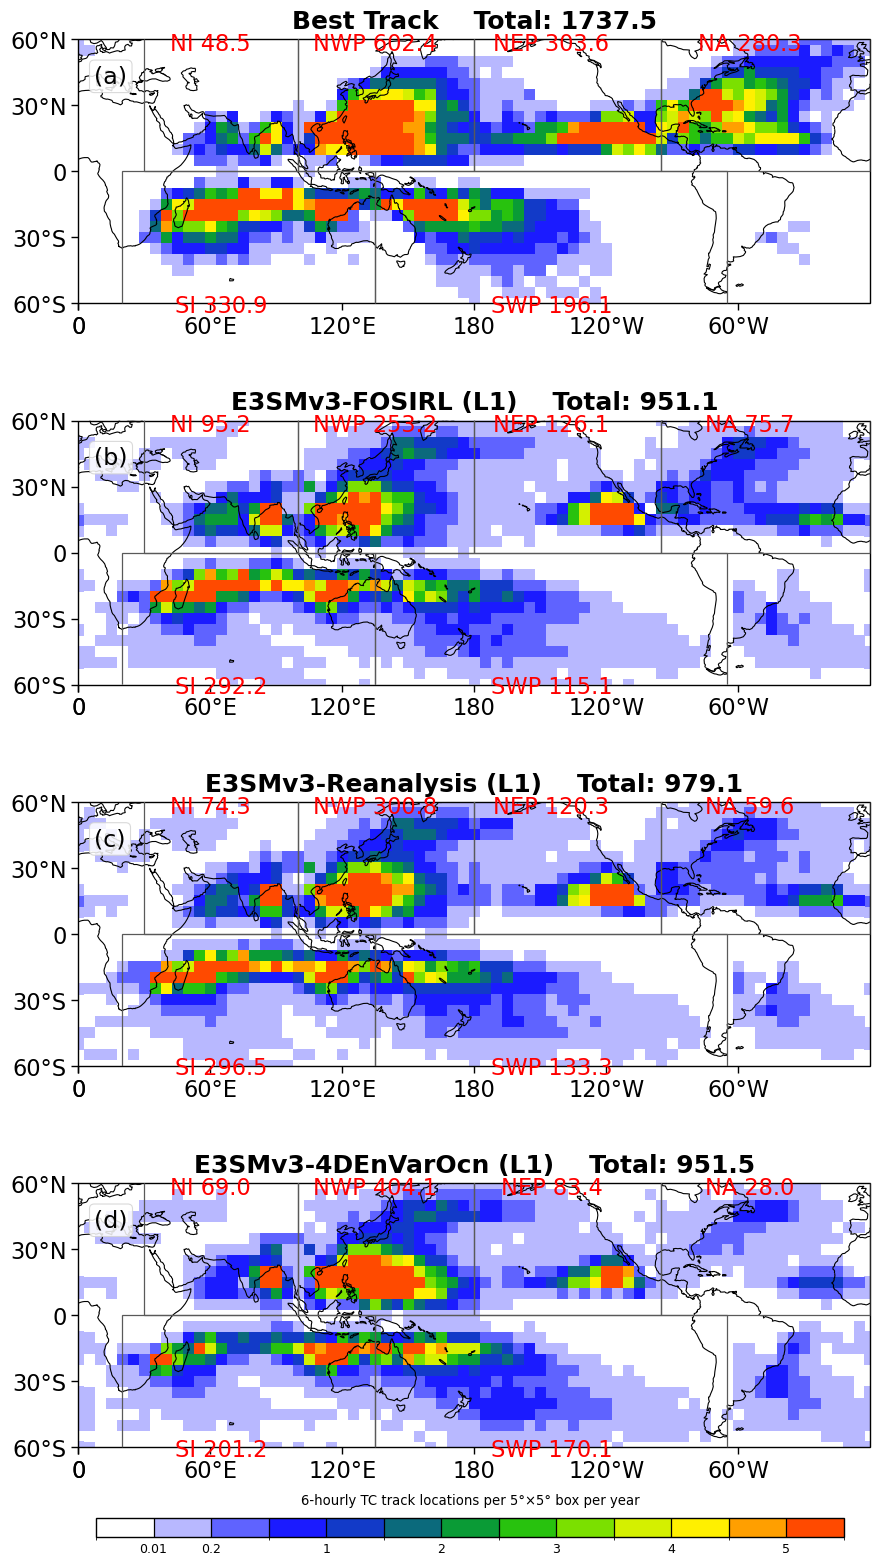

Annual-mean basin-integrated TC track-point density summary: 1980-2011, lead month 1


,lead,E3SMv3-FOSIRL,E3SMv3-Reanalysis,E3SMv3-4DEnVarOcn,BestTrack,E3SMv3-FOSIRL/BestTrack,E3SMv3-Reanalysis/BestTrack,E3SMv3-4DEnVarOcn/BestTrack
basin,,,,,,,,
NWP,1,174.912500,228.481250,308.653125,489.78125,0.357124,0.466497,0.630186
NA,1,55.090625,42.618750,16.087500,237.31250,0.232144,0.179589,0.067790
EP,1,112.128125,109.003125,71.240625,260.81250,0.429919,0.417937,0.273149
NI,1,75.984375,58.512500,58.790625,27.65625,2.747458,2.115706,2.125763
SI,1,277.509375,282.787500,183.993750,298.15625,0.930751,0.948454,0.617105
SP,1,101.293750,119.543750,144.509375,183.40625,0.552292,0.651798,0.787920


Saved basin summary table: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/tropical_cyclones/tables/tc_basin_annual_density_lead1_1980_2011.csv


In [10]:
def figure_filename(*parts, ext="png"):
    """Build consistent, readable lowercase snake_case figure filenames."""
    import re

    clean_parts = ["fig"]
    for part in parts:
        if part is None:
            continue
        text = str(part).strip()
        if not text:
            continue
        text = re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()
        if text:
            clean_parts.append(text)

    suffix = ext.lstrip(".").lower()
    return "_".join(clean_parts) + f".{suffix}"


# =================================================================== #
#  SETUP & PLOT CONTROLS
# =================================================================== #
DENSITY_COMPARE_CASES = [
    k for k in E3SM_HINDCASTS if E3SM_HINDCASTS[k].get("enabled", True)
]

# Basin boxes and label alignment (perfectly aligned horizontally inside +/-60 map extent)
MAIN_BASINS = {
    "NA":  {"lon1": 265, "lon2": 360, "lat1": 0,   "lat2": 90, "text_xy": (312, 51)},
    "NEP": {"lon1": 180, "lon2": 265, "lat1": 0,   "lat2": 90, "text_xy": (222, 51)},
    "NWP": {"lon1": 100, "lon2": 180, "lat1": 0,   "lat2": 90, "text_xy": (140, 51)},
    "NI":  {"lon1": 30,  "lon2": 100, "lat1": 0,   "lat2": 90, "text_xy": (65, 51)},
    "SI":  {"lon1": 20,  "lon2": 135, "lat1": -90, "lat2": 0,  "text_xy": (78, -51)},
    "SWP": {"lon1": 135, "lon2": 295, "lat1": -90, "lat2": 0,  "text_xy": (215, -51)},
}
BASINS = MAIN_BASINS.copy()
if globals().get("INCLUDE_SOUTH_ATLANTIC_BASINS", False):
    BASINS.update({
        "SA1": {"lon1": 295, "lon2": 360, "lat1": -90, "lat2": 0,  "text_xy": (328, -35)},
        "SA2": {"lon1": 0,   "lon2": 20,  "lat1": 0,   "lat2": 90, "text_xy": (10, 51)},
    })
PLOT_LEAD = 1
PLOT_SEASON = "NH_JJASON"
MIN_PLOT_VALUE = 0.01

# Panel title format: e.g. E3SMv3-FOSIRL (L1)
DENSITY_PANEL_TITLE_FMT = "{label} (L{lead})    Total: {total:.1f}"

# Projection and map extent
CENTRAL_LONGITUDE = 180
MAP_EXTENT = [0, 360, -60, 60]

# Figure dimensions and layout (4 rows: Obs + 3 models)
PLOT_NROWS = 1 + len(DENSITY_COMPARE_CASES)
PLOT_NCOLS = 1
FIGSIZE = (8.8, 3.8 * PLOT_NROWS + 1.0) if PLOT_NCOLS == 1 else (16.0, 4.2 * PLOT_NROWS + 0.8)
SUBPLOT_ADJUST = (
    dict(left=0.08, right=0.98, top=0.96, bottom=0.07, hspace=0.28)
    if PLOT_NCOLS == 1
    else dict(left=0.05, right=0.98, top=0.95, bottom=0.10, hspace=0.25, wspace=0.10)
)
COLORBAR_AX_POSITION = [0.10, 0.025, 0.85, 0.012] if PLOT_NCOLS == 1 else [0.15, 0.035, 0.70, 0.022]

# Typography
FONTZ = 10.0
COLORBAR_TITLE_FONTSIZE = 0.95 * FONTZ
COLORBAR_TICK_FONTSIZE = 0.90 * FONTZ

# Colormap & discrete bounds (original colorbar styles restored)
COLORBAR_BOUNDS = [
    0.0, 0.01, 0.2, 0.5, 1.0, 1.5, 2.0,
    2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0,
]
COLORBAR_TICKS = [0.01, 0.2, 1, 2, 3, 4, 5]
COLORBAR_TICK_LABELS = ["0.01", "0.2", "1", "2", "3", "4", "5"]
COLORBAR_COLORS = [
    "white",
    "#b8b8ff",
    "#5f63ff",
    "#1b1bff",
    "#123ac8",
    "#0b6a7c",
    "#0a9b36",
    "#28c20e",
    "#7be000",
    "#d4f000",
    "#fff000",
    "#ff9f00",
    "#ff4a00",
]
COLORBAR_TITLE_PAD = 10
COLORBAR_OUTLINE_WIDTH = 1.0
COLORBAR_DIVIDER_WIDTH = 0.9
DPI = 200

# Figure saving and metadata
LEADTIME_METRIC = "tc_leadtime_track_density_compare"
LEADTIME_SAVE_MODE = "tc"
LEADTIME_SAVE_TITLE = "Multi-Model TC Lead-Time Track Density Comparison"
LEADTIME_SAVE_CAPTION = (
    f"Annual global TC track density comparison between Best Track and E3SM hindcasts "
    f"({', '.join(E3SM_HINDCASTS[k]['label'] for k in DENSITY_COMPARE_CASES)}) at lead month {PLOT_LEAD}."
)
LEADTIME_SAVE_KW = dict(
    mode=LEADTIME_SAVE_MODE,
    metric=LEADTIME_METRIC,
    title=LEADTIME_SAVE_TITLE,
    caption=LEADTIME_SAVE_CAPTION,
    dpi=DPI,
)

expected_diagnostic_paths = {
    key: hindcast_diag_path(key)
    for key in DENSITY_COMPARE_CASES
    if E3SM_HINDCASTS[key].get("enabled", True)
}
needs_distributed_compute = (
    DASK_SETTINGS["enabled"]
    and TC_DIAGNOSTIC_MODE != "require"
    and (
        TC_DIAGNOSTIC_MODE == "rebuild"
        or any(not path.is_file() for path in expected_diagnostic_paths.values())
    )
)
cluster, client, workflow_resources = restart_notebook_cluster(
    globals(),
    lambda: get_cluster_client(DaskConfig(
        cluster_type=DASK_SETTINGS["cluster_type"],
        workers=DASK_SETTINGS["workers"],
        cores=DASK_SETTINGS["cores"],
        memory_limit=DASK_SETTINGS["memory_limit"],
    )) if needs_distributed_compute else (None, None),
)
if not needs_distributed_compute and DASK_SETTINGS["enabled"]:
    print("All exact-period TC caches are valid; skipped Dask cluster startup.")
try:
    TC_DIAGNOSTIC_REPORT = ensure_configured_experiment_diagnostics(
        dask_client=client
    )
finally:
    close_notebook_resources(globals())
    print("Closed Dask resources after TC diagnostic preparation.")

DIAG_DATASETS = {
    case_key: _load_first_figure_case(case_key)
    for case_key in DENSITY_COMPARE_CASES
}
PRIMARY_DIAG = DIAG_DATASETS.get(PRIMARY_CASE_KEY, next(iter(DIAG_DATASETS.values())))
REFERENCE_DIAG = DIAG_DATASETS.get(REFERENCE_CASE_KEY, None)

OBS_DIAG = next(
    (ds for ds in DIAG_DATASETS.values() if "obs_track_density_count" in ds),
    None,
)
if OBS_DIAG is None:
    raise ValueError(
        "No loaded E3SM cache contains the IBTrACS companion variables. "
        "Run Section 8 for at least one case."
    )

# ============================================================
# Year selection
# ============================================================
diag_years = None
for ds in DIAG_DATASETS.values():
    y_vals = ds.year.astype(int).values
    diag_years = y_vals if diag_years is None else np.intersect1d(diag_years, y_vals)

plot_years = np.intersect1d(REQUESTED_YEARS, diag_years)

if plot_years.size == 0:
    raise ValueError(
        f"No overlap between requested years {REQUESTED_YEARS[0]}-{REQUESTED_YEARS[-1]} "
        f"and the common E3SM diagnostic years."
    )

if plot_years[0] != REQUESTED_YEARS[0] or plot_years[-1] != REQUESTED_YEARS[-1]:
    print(
        f"Requested {REQUESTED_YEARS[0]}-{REQUESTED_YEARS[-1]}, "
        f"but common E3SM coverage is {diag_years.min()}-{diag_years.max()}; "
        f"plotting {plot_years[0]}-{plot_years[-1]} ({plot_years.size} years)."
    )

# ============================================================
# Select model and observation count/sample arrays
# ============================================================
case_counts = {}
case_samples = {}
case_storm_counts = {}
case_valid_season_year = {}

for case_key, ds in DIAG_DATASETS.items():
    case_counts[case_key] = ds["tc_track_density_count"].sel(
        lead=PLOT_LEAD,
        year=plot_years,
        season=REQUIRED_SEASONS,
    )
    case_samples[case_key] = ds["sample_count"].sel(
        lead=PLOT_LEAD,
        year=plot_years,
        season=REQUIRED_SEASONS,
    )
    case_storm_counts[case_key] = ds["tc_storm_count"].sel(
        lead=PLOT_LEAD,
        year=plot_years,
        season=REQUIRED_SEASONS,
    )
    case_valid_season_year[case_key] = case_samples[case_key] > 0

obs_count = OBS_DIAG["obs_track_density_count"].sel(
    year=plot_years,
    season=REQUIRED_SEASONS,
)
obs_sample = OBS_DIAG["obs_sample_count"].sel(
    year=plot_years,
    season=REQUIRED_SEASONS,
)
obs_storm_count = OBS_DIAG["obs_storm_count"].sel(
    year=plot_years,
    season=REQUIRED_SEASONS,
)

# ============================================================
# Apply model-valid season/year mask before model-vs-observation comparison
# ============================================================
valid_annual_year = None
for case_key in DENSITY_COMPARE_CASES:
    c_valid = case_valid_season_year[case_key].all("season")
    valid_annual_year = c_valid if valid_annual_year is None else (valid_annual_year & c_valid)

valid_year_values = valid_annual_year.year.values[valid_annual_year.values]

if valid_year_values.size == 0:
    raise ValueError(
        f"No years have both {REQUIRED_SEASONS} sampled by all E3SM cases at lead {PLOT_LEAD}."
    )

if valid_year_values.size != plot_years.size:
    dropped = sorted(set(plot_years.tolist()) - set(valid_year_values.tolist()))
    print(
        f"Lead {PLOT_LEAD}: dropping years without both seasons sampled by all E3SM cases: {dropped}"
    )

plot_years = valid_year_values

comparison_valid_season_year = None
for case_key in DENSITY_COMPARE_CASES:
    v_mask = case_valid_season_year[case_key].sel(year=plot_years)
    case_counts[case_key] = case_counts[case_key].sel(year=plot_years).where(v_mask)
    case_samples[case_key] = case_samples[case_key].sel(year=plot_years)
    case_storm_counts[case_key] = case_storm_counts[case_key].sel(year=plot_years).where(v_mask)
    comparison_valid_season_year = (
        v_mask if comparison_valid_season_year is None else (comparison_valid_season_year & v_mask)
    )

obs_count = obs_count.sel(year=plot_years).where(comparison_valid_season_year)
obs_sample = obs_sample.sel(year=plot_years).where(comparison_valid_season_year)
obs_storm_count = obs_storm_count.sel(year=plot_years).where(comparison_valid_season_year)

# ============================================================
# Combine NH + SH into annual global TC-season count maps
# ============================================================
case_annual_counts = {}
case_annual_samples = {}
case_annual_storm_counts = {}
case_annual_densities = {}
case_annual_storm_means = {}
case_fields = {}
case_totals = {}

for case_key in DENSITY_COMPARE_CASES:
    v_mask = case_valid_season_year[case_key].sel(year=plot_years)
    ann_cnt = case_counts[case_key].sum("season", skipna=True, min_count=1)
    ann_samp = case_samples[case_key].where(v_mask).min("season", skipna=True)
    ann_stm_cnt = case_storm_counts[case_key].sum("season", skipna=True, min_count=1)

    ann_dens = ann_cnt / ann_samp.where(ann_samp > 0)
    ann_stm_mean = ann_stm_cnt / ann_samp.where(ann_samp > 0)
    fld = ann_dens.mean("year", skipna=True)
    tot = float(fld.sum(("lat", "lon"), skipna=True))

    case_annual_counts[case_key] = ann_cnt
    case_annual_samples[case_key] = ann_samp
    case_annual_storm_counts[case_key] = ann_stm_cnt
    case_annual_densities[case_key] = ann_dens
    case_annual_storm_means[case_key] = ann_stm_mean
    case_fields[case_key] = fld
    case_totals[case_key] = tot

    spread = case_samples[case_key].max("season", skipna=True) - case_samples[case_key].min("season", skipna=True)
    if float(spread.max()) != 0:
        lbl = E3SM_HINDCASTS[case_key]["label"]
        print(
            f"Warning: {lbl} NH and SH sample counts differ for at least one year. "
            f"Using the smaller annual sample count."
        )

obs_annual_count = obs_count.sum("season", skipna=True, min_count=1)
obs_annual_sample = obs_sample.min("season", skipna=True)
obs_annual_storm_count = obs_storm_count.sum("season", skipna=True, min_count=1)
obs_annual_density = obs_annual_count / obs_annual_sample.where(obs_annual_sample > 0)
obs_annual_storm_mean = obs_annual_storm_count / obs_annual_sample.where(obs_annual_sample > 0)
obs_field = obs_annual_density.mean("year", skipna=True)
obs_total = float(obs_field.sum(("lat", "lon"), skipna=True))

obs_sample_spread = obs_sample.max("season", skipna=True) - obs_sample.min("season", skipna=True)
if float(obs_sample_spread.max()) != 0:
    print(
        "Warning: obs NH and SH sample counts differ for at least one year. "
        "Using the smaller annual sample count."
    )

# Backward-compatibility convenience variables
if PRIMARY_CASE_KEY in case_fields:
    model_count = case_counts[PRIMARY_CASE_KEY]
    model_sample = case_samples[PRIMARY_CASE_KEY]
    model_storm_count = case_storm_counts[PRIMARY_CASE_KEY]
    model_annual_count = case_annual_counts[PRIMARY_CASE_KEY]
    model_annual_sample = case_annual_samples[PRIMARY_CASE_KEY]
    model_annual_storm_count = case_annual_storm_counts[PRIMARY_CASE_KEY]
    model_annual_density = case_annual_densities[PRIMARY_CASE_KEY]
    model_annual_storm_mean = case_annual_storm_means[PRIMARY_CASE_KEY]
    model_field = case_fields[PRIMARY_CASE_KEY]
    model_total = case_totals[PRIMARY_CASE_KEY]

if REFERENCE_CASE_KEY and REFERENCE_CASE_KEY in case_fields:
    reference_count = case_counts[REFERENCE_CASE_KEY]
    reference_sample = case_samples[REFERENCE_CASE_KEY]
    reference_storm_count = case_storm_counts[REFERENCE_CASE_KEY]
    reference_annual_count = case_annual_counts[REFERENCE_CASE_KEY]
    reference_annual_sample = case_annual_samples[REFERENCE_CASE_KEY]
    reference_annual_storm_count = case_annual_storm_counts[REFERENCE_CASE_KEY]
    reference_annual_density = case_annual_densities[REFERENCE_CASE_KEY]
    reference_annual_storm_mean = case_annual_storm_means[REFERENCE_CASE_KEY]
    reference_field = case_fields[REFERENCE_CASE_KEY]
    reference_total = case_totals[REFERENCE_CASE_KEY]

# ============================================================
# Diagnostics
# ============================================================

print(
    f"Lead {PLOT_LEAD} valid comparison years: "
    f"{int(plot_years[0])}-{int(plot_years[-1])} ({plot_years.size} years)."
)
print(f"Lead {PLOT_LEAD} annual sample count after common-cohort masking:")
for k in DENSITY_COMPARE_CASES:
    print(f"  {E3SM_HINDCASTS[k]['label']} mean={float(case_annual_samples[k].mean()):.1f}")
print(f"  Best Track mean={float(obs_annual_sample.mean()):.1f}.")

print("\nAnnual global detected storm counts (NH_JJASON + SH_DJFMAM):")
for k in DENSITY_COMPARE_CASES:
    lbl = E3SM_HINDCASTS[k]["label"]
    raw_acc = float(case_annual_storm_counts[k].mean("year", skipna=True))
    per_real = float(case_annual_storm_means[k].mean("year", skipna=True))
    print(f"  {lbl:<26} raw accumulated: {raw_acc:.1f}, per-realization mean: {per_real:.1f}")
print(f"  {'Best Track observed mean:':<26} {float(obs_annual_storm_mean.mean('year', skipna=True)):.1f}")

print(
    f"\nAnnual global TC track-density map totals "
    f"summed over all {DIAG_GRID_SIZE:g}°×{DIAG_GRID_SIZE:g} grid points:"
)
for k in DENSITY_COMPARE_CASES:
    lbl = E3SM_HINDCASTS[k]["label"]
    raw_acc = float(case_annual_counts[k].sum(("lat", "lon"), skipna=True).mean("year"))
    per_real = case_totals[k]
    print(f"  {lbl:<26} raw accumulated: {raw_acc:.1f}, per-realization mean: {per_real:.1f}")
print(f"  {'Best Track observed mean:':<26} {obs_total:.1f}")
print("  Note: this is not an annual storm count; one storm can contribute to multiple grid points.")

for k in DENSITY_COMPARE_CASES:
    lbl = E3SM_HINDCASTS[k]["label"]
    print(f"\n{lbl} annual sample count summary:")
    display(case_annual_samples[k].to_series().describe())

print("\nObs annual sample count summary:")
display(obs_annual_sample.to_series().describe())

# ============================================================
# Colormap
# ============================================================

cmap = mcolors.ListedColormap(COLORBAR_COLORS)
cmap.set_bad((1, 1, 1, 0))
norm = mcolors.BoundaryNorm(COLORBAR_BOUNDS, cmap.N)

# ============================================================
# Plot Best Track and E3SM Hindcasts
# ============================================================

fig, axes = plt.subplots(
    PLOT_NROWS,
    PLOT_NCOLS,
    figsize=FIGSIZE,
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=CENTRAL_LONGITUDE)},
)
axes = np.asarray(axes).ravel()

letters = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)"]
plot_items = [
    (
        obs_field,
        obs_field.where(obs_field >= MIN_PLOT_VALUE),
        f"{OBS_LABEL}    Total: {obs_total:.1f}",
        letters[0],
    ),
]
for idx, case_key in enumerate(DENSITY_COMPARE_CASES):
    lbl = E3SM_HINDCASTS[case_key]["label"]
    fld = case_fields[case_key]
    tot = case_totals[case_key]
    pan_title = DENSITY_PANEL_TITLE_FMT.format(
        label=lbl, lead=PLOT_LEAD, total=tot
    )
    pan_letter = letters[idx + 1] if idx + 1 < len(letters) else f"({chr(97 + idx + 1)})"
    plot_items.append((
        fld,
        fld.where(fld >= MIN_PLOT_VALUE),
        pan_title,
        pan_letter,
    ))

im = None
for ax, (raw_field, plot_field, title, panel_label) in zip(axes, plot_items):
    im = plot_field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
    )
    _format_tc_density_axis(ax, title, panel_label, raw_field)

# Hide any unused subplot axes if grid size > items
for ax in axes[len(plot_items):]:
    ax.set_visible(False)

# Shared bottom boxed colorbar, placed in a dedicated axis so it does not
# overlap the lower map panel.
cbar_ax = fig.add_axes(COLORBAR_AX_POSITION)
cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation="horizontal",
    boundaries=COLORBAR_BOUNDS,
    ticks=COLORBAR_TICKS,
    spacing="uniform",
    drawedges=True,
)

cbar.ax.set_title(DENSITY_LABEL, fontsize=COLORBAR_TITLE_FONTSIZE, pad=COLORBAR_TITLE_PAD)
cbar.ax.set_xticklabels(COLORBAR_TICK_LABELS, fontsize=COLORBAR_TICK_FONTSIZE)
cbar.ax.tick_params(length=0)

cbar.outline.set_linewidth(COLORBAR_OUTLINE_WIDTH)
if hasattr(cbar, "dividers"):
    cbar.dividers.set_color("black")
    cbar.dividers.set_linewidth(COLORBAR_DIVIDER_WIDTH)

import esp_lab.utils.mov_utils as mov
figname = figure_filename(LEADTIME_METRIC)
figpath = FIGURE_OUTDIR / figname
mov.save_figure(fig, figpath, **LEADTIME_SAVE_KW)
print("Saved figure:", figpath)
fig.subplots_adjust(**SUBPLOT_ADJUST)
plt.show()

# ============================================================
# Basin-integrated annual mean TC track density
# ============================================================

basin_dict = {}
for case_key in DENSITY_COMPARE_CASES:
    lbl = E3SM_HINDCASTS[case_key]["label"]
    ds = DIAG_DATASETS[case_key]
    b_count = ds["tc_basin_track_density_count"].sel(
        lead=PLOT_LEAD, year=plot_years, season=REQUIRED_SEASONS
    )
    v_mask = case_valid_season_year[case_key].sel(year=plot_years)
    b_count = b_count.where(v_mask)
    b_ann_count = b_count.sum("season", skipna=True, min_count=1)
    ann_samp = case_annual_samples[case_key]
    b_ann_density = b_ann_count / ann_samp.where(ann_samp > 0)
    basin_dict[lbl] = b_ann_density.mean("year", skipna=True)

obs_basin_count = OBS_DIAG["obs_basin_track_density_count"].sel(
    year=plot_years, season=REQUIRED_SEASONS
).where(comparison_valid_season_year)
obs_basin_annual_count = obs_basin_count.sum("season", skipna=True, min_count=1)
obs_basin_annual_density = obs_basin_annual_count / obs_annual_sample.where(obs_annual_sample > 0)
basin_dict["BestTrack"] = obs_basin_annual_density.mean("year", skipna=True)

basin_summary = xr.Dataset(basin_dict).to_dataframe()

active_cols = [c for c in basin_summary.columns if c != "BestTrack"]
basin_summary = basin_summary[
    (basin_summary[active_cols] != 0).any(axis=1) | (basin_summary["BestTrack"] != 0)
].copy()

for case_key in DENSITY_COMPARE_CASES:
    lbl = E3SM_HINDCASTS[case_key]["label"]
    basin_summary[f"{lbl}/BestTrack"] = basin_summary[lbl] / basin_summary["BestTrack"]

print(
    f"Annual-mean basin-integrated TC track-point density summary: "
    f"{plot_years[0]}-{plot_years[-1]}, lead month {PLOT_LEAD}"
)

display(basin_summary)

basin_summary_file = TABLE_OUTDIR / f"tc_basin_annual_density_lead{PLOT_LEAD}_{plot_years[0]}_{plot_years[-1]}.csv"
basin_summary.to_csv(basin_summary_file)
print(f"Saved basin summary table: {basin_summary_file}")


## 9. ENSO regression diagnostics

This block follows Yeager et al. Fig. 14: regress seasonal-mean TC track density on the corresponding seasonal-mean Niño-3.4 index, using JJASON in the Northern Hemisphere and DJFMAM in the Southern Hemisphere. The figure compares E3SMv3-FOSIRL and E3SMv3-Reanalysis against one shared Best Track panel. By default, it shows the full regression slope fields and overlays 90% significant cells; set `PLOT_SIGNIFICANT_ONLY = True` only when you want a strict Yeager-caption mask.

The original Yeager et al. panel uses 1971-2018.  This notebook uses the configured diagnostic window (`years`-`yeare`; currently 1980-2018) unless you regenerate `DS_DIAG` for a longer period.  At 19-month lead, the final target season may be partial when the forecast files are only 24 months long: November starts contribute JJASO rather than JJASON, and May starts contribute DJFMA rather than DJFMAM.

For archives with only May/November starts, the available Yeager-style seasonal leads are `1, 7, 13, 19`; the plotting cell automatically drops leads with no model samples.

Set `NINO_FILE` to your Niño index NetCDF.  A monthly Niño-3.4 file is preferred so the code can average JJASON for `NH_JJASON` and DJFMAM for `SH_DJFMAM`; yearly input is accepted as a fallback.


In [11]:
from scipy.stats import t as student_t

def _guess_nino_var(ds: xr.Dataset) -> str:
    """Pick a likely Niño variable if NINO_VAR is not set."""
    preferred = ["nino34_ann", "nino34", "nino", "nino34_index", "oni"]
    for name in preferred:
        if name in ds.data_vars:
            return name
    one_dim = [name for name, da in ds.data_vars.items() if da.ndim == 1]
    if len(one_dim) == 1:
        return one_dim[0]
    raise ValueError(
        "Could not infer Niño variable. Set NINO_VAR to one of: "
        + ", ".join(ds.data_vars)
    )

def load_seasonal_nino_index(
    path: Path,
    varname: str | None = None,
    clim_years: tuple[int, int] | None = None,
) -> xr.DataArray:
    """Load Niño index as DataArray(season, year), averaged over TC seasons."""
    if not path.is_file():
        raise FileNotFoundError(f"Niño index file not found: {path}")
    ds = xr.open_dataset(path)
    varname = varname or _guess_nino_var(ds)
    da = ds[varname]

    if "time" not in da.dims and "year" not in da.dims:
        dim = da.dims[0]
        coord = da[dim].values if dim in da.coords else np.arange(da.sizes[dim])
        if np.issubdtype(np.asarray(coord).dtype, np.datetime64):
            da = da.rename({dim: "time"}).assign_coords(time=coord)
        else:
            da = da.assign_coords(year=(dim, coord.astype(int))).swap_dims({dim: "year"}).drop_vars(dim, errors="ignore")

    extra_dims = [d for d in da.dims if d not in ("time", "year")]
    if extra_dims:
        da = da.mean(extra_dims)

    if "time" in da.dims:
        # Keep xarray's datetime accessor so both numpy datetime64 and
        # cftime calendars (used by HadISST2 here) are supported.
        month = da["time"].dt.month.values.astype(int)
        year = da["time"].dt.year.values.astype(int)

        if clim_years is not None:
            clim_start, clim_end = clim_years
            clim_mask = (year >= clim_start) & (year <= clim_end)
            if not np.any(clim_mask):
                raise ValueError(
                    f"No Niño data fall within climatology years {clim_start}-{clim_end}."
                )
            monthly_clim = da.isel(time=clim_mask).groupby("time.month").mean("time")
            da = da.groupby("time.month") - monthly_clim
            print(f"Removed {clim_start}-{clim_end} monthly Niño-3.4 climatology.")

        nh_mask = np.isin(month, [6, 7, 8, 9, 10, 11])

        nh = (
            da.isel(time=nh_mask)
            .assign_coords(year=("time", year[nh_mask]))
            .groupby("year")
            .mean("time")
        )

        sh_mask = np.isin(month, [12, 1, 2, 3, 4, 5])
        sh_year = np.where(month == 12, year, year - 1)
        sh = (
            da.isel(time=sh_mask)
            .assign_coords(year=("time", sh_year[sh_mask]))
            .groupby("year")
            .mean("time")
        )

        season_coord = xr.DataArray(season_names, dims="season", name="season")
        nino = xr.concat([nh, sh], dim=season_coord, join="outer")
    elif "year" in da.dims:
        yearly = da.rename({"year": "year"})
        season_coord = xr.DataArray(season_names, dims="season", name="season")
        nino = xr.concat([yearly, yearly], dim=season_coord, join="exact")
        print("Niño input is yearly; using the same yearly index for both TC seasons.")

    nino = nino.astype(float).sortby("year").transpose("season", "year")
    nino.name = "seasonal_nino34_index"
    nino.attrs.update({
        "source_file": str(path),
        "source_variable": varname,
        "monthly_climatology": (
            f"{clim_years[0]}-{clim_years[1]}" if clim_years is not None else "not removed"
        ),
    })
    return nino

def regression_tcrit(n: xr.DataArray, confidence: float = SIG_CONFIDENCE) -> xr.DataArray:
    """Two-sided Student-t threshold for correlation/slope significance."""
    alpha = 1.0 - confidence
    return xr.apply_ufunc(
        lambda n_: student_t.ppf(1.0 - alpha / 2.0, np.maximum(n_ - 2, 1)),
        n.astype(float),
        vectorize=True,
        dask="allowed",
    ).where(n >= 3)

def xr_regress_y_on_x(y: xr.DataArray, x: xr.DataArray, sample_dim: str = "year") -> xr.Dataset:
    """
    Regress y against x along sample_dim.

    Returns slope, intercept, correlation, t-value for correlation/slope, and n.
    The t-value is r * sqrt((n - 2) / (1 - r**2)).
    """
    x, y = xr.align(x, y, join="inner")
    valid = np.isfinite(x) & np.isfinite(y)

    n = valid.sum(sample_dim)
    x_valid = x.where(valid)
    y_valid = y.where(valid)

    x_mean = x_valid.mean(sample_dim, skipna=True)
    y_mean = y_valid.mean(sample_dim, skipna=True)
    x_anom = x_valid - x_mean
    y_anom = y_valid - y_mean

    cov_xy = (x_anom * y_anom).sum(sample_dim, skipna=True)
    var_x = (x_anom ** 2).sum(sample_dim, skipna=True)
    var_y = (y_anom ** 2).sum(sample_dim, skipna=True)

    slope = (cov_xy / var_x).where(n >= 3)
    intercept = (y_mean - slope * x_mean).where(n >= 3)
    corr = cov_xy / np.sqrt(var_x * var_y)
    corr = corr.where(n >= 3)

    tval = corr * np.sqrt((n - 2) / (1 - corr ** 2))
    tval = tval.where(n >= 3)

    return xr.Dataset({
        "slope": slope,
        "intercept": intercept,
        "corr": corr,
        "tval": tval,
        "n": n,
    })

# Yeager-style Fig. 14 regression panel: BestTrack plus E3SM lead months.
# Default: plot the full regression slope field so weak model responses remain visible,
# and overlay small black markers where cells pass the 90% two-sided significance test.
# Set PLOT_SIGNIFICANT_ONLY=True to reproduce a strict significant-shading-only view.
# At 19-month lead, available 24-month forecasts may represent JJASO/DJFMA partial target seasons.
import matplotlib.colors as mcolors

def regression_diag_path(case_key):
    spec = E3SM_HINDCASTS[case_key]
    return (
        E3SMLE_OUTDIR / case_key / "tc_track"
        / (
            f"tc_lead_track_density_enso_regression_{spec['case_prefix']}_"
            f"{PARSET}_{years}_{yeare}_{REG_NINO_LABEL}.nc"
        )
    )


def build_regression_diagnostic(case_key, *, force=False):
    """Build one exact-period ENSO regression diagnostic from its density cache."""
    if case_key not in E3SM_HINDCASTS:
        raise KeyError(f"Unknown regression case: {case_key!r}")

    regression_path = regression_diag_path(case_key)
    if regression_path.is_file() and not force:
        print(f"Reusing regression diagnostic: {regression_path}")
        return _load_netcdf_fully(regression_path)

    density_path = hindcast_diag_path(case_key)
    if not density_path.is_file():
        raise FileNotFoundError(
            f"Missing exact-period track-density diagnostic for "
            f"{E3SM_HINDCASTS[case_key]['label']}: {density_path}"
        )

    ds_diag = _load_netcdf_fully(density_path)
    required_vars = {"tc_track_density_mean", "obs_track_density_mean"}
    missing_vars = required_vars.difference(ds_diag.data_vars)
    if missing_vars:
        raise ValueError(
            f"{density_path} is missing required variables: {sorted(missing_vars)}"
        )

    case_nino_index = load_seasonal_nino_index(
        Path(NINO_FILE), NINO_VAR, clim_years=NINO_CLIM_YEARS
    )
    analysis_years = np.asarray(
        [year for year in range(years, yeare + 1) if yexcl is None or year != yexcl],
        dtype=int,
    )
    common_years = np.intersect1d(
        np.intersect1d(analysis_years, ds_diag.year.astype(int).values),
        case_nino_index.year.astype(int).values,
    )
    if common_years.size < 3:
        raise ValueError(
            f"Need at least 3 overlapping years for {case_key}; found {common_years.size}."
        )

    ds_diag = ds_diag.sel(year=common_years)
    case_nino_index = case_nino_index.sel(year=common_years)
    model_density = ds_diag["tc_track_density_mean"]
    if "sample_count" in ds_diag:
        model_density = model_density.where(ds_diag["sample_count"] > 0)

    reg_model = xr_regress_y_on_x(model_density, case_nino_index)
    reg_obs = xr_regress_y_on_x(ds_diag["obs_track_density_mean"], case_nino_index)
    model_tcrit = regression_tcrit(reg_model["n"])
    obs_tcrit = regression_tcrit(reg_obs["n"])

    ds_reg = xr.Dataset({
        "model_slope": reg_model["slope"],
        "model_intercept": reg_model["intercept"],
        "model_corr": reg_model["corr"],
        "model_tval": reg_model["tval"],
        "model_n": reg_model["n"],
        "model_sample_count": (
            ds_diag["sample_count"] if "sample_count" in ds_diag else reg_model["n"]
        ),
        "obs_slope": reg_obs["slope"],
        "obs_intercept": reg_obs["intercept"],
        "obs_corr": reg_obs["corr"],
        "obs_tval": reg_obs["tval"],
        "obs_n": reg_obs["n"],
        "model_tcrit_90": model_tcrit,
        "obs_tcrit_90": obs_tcrit,
        "model_slope_sig": reg_model["slope"].where(
            np.abs(reg_model["tval"]) >= model_tcrit, 0.0
        ),
        "obs_slope_sig": reg_obs["slope"].where(
            np.abs(reg_obs["tval"]) >= obs_tcrit, 0.0
        ),
        "nino_index": case_nino_index,
    })
    ds_reg.attrs.update({
        "description": (
            "Regression of TC-season track-density diagnostics against Niño-3.4 "
            "averaged over the corresponding TC season."
        ),
        "case_key": case_key,
        "nino_file": str(NINO_FILE),
        "nino_variable": case_nino_index.attrs.get("source_variable", "unknown"),
        "significance_confidence_level": SIG_CONFIDENCE,
        "significance_test": "two-sided Student-t test using n - 2 degrees of freedom",
        "sample_mask": "Model regression masks tc_track_density_mean where sample_count <= 0.",
        "density_file": str(density_path),
        "analysis_years": f"{common_years.min()}-{common_years.max()}",
    })
    write_netcdf(ds_reg, regression_path, overwrite=True)
    print(f"Saved regression diagnostic: {regression_path}")
    return ds_reg


def _lon_label(x):
    x = int(x) % 360
    if x == 0:
        return "0"
    if x == 180:
        return "180"
    return f"{x}°E" if x < 180 else f"{360 - x}°W"

def _lat_label(y):
    y = int(y)
    if y == 0:
        return "0"
    return f"{abs(y)}°N" if y > 0 else f"{abs(y)}°S"

def _coord_edges(coord):
    coord = np.asarray(coord, dtype=float)
    mids = 0.5 * (coord[:-1] + coord[1:])
    first = coord[0] - 0.5 * (coord[1] - coord[0])
    last = coord[-1] + 0.5 * (coord[-1] - coord[-2])
    return np.concatenate([[first], mids, [last]])

def _field_for_pcolormesh(field):
    field = field.transpose("lat", "lon")
    lon = field["lon"].values
    lat = field["lat"].values
    return field.values, _coord_edges(lon), _coord_edges(lat)

def _plot_sig_markers(ax, sig):
    if not PLOT_SIGNIFICANCE_MARKERS:
        return
    sig = sig.transpose("lat", "lon")
    sig_values = sig.values.astype(bool)
    if PLOT_MARKER_STRIDE > 1:
        keep = np.zeros_like(sig_values, dtype=bool)
        keep[::PLOT_MARKER_STRIDE, ::PLOT_MARKER_STRIDE] = True
        sig_values &= keep
    yy, xx = np.where(sig_values)
    if yy.size == 0:
        return
    ax.scatter(
        sig["lon"].values[xx], sig["lat"].values[yy],
        s=SIG_MARKER_SIZE, marker=SIG_MARKER_STYLE, color=SIG_MARKER_COLOR, alpha=SIG_MARKER_ALPHA,
        linewidths=SIG_MARKER_LINEWIDTH, transform=ccrs.PlateCarree(), zorder=5,
    )

def _plot_regression_panel(ax, field, sig, title, panel_label, show_basin_boxes=False):
    data, lon_edges, lat_edges = _field_for_pcolormesh(field)
    has_data = np.isfinite(data).any()
    im = ax.pcolormesh(
        lon_edges, lat_edges, data,
        cmap=cmap,
        norm=mcolors.BoundaryNorm(LEVELS, cmap.N),
        transform=ccrs.PlateCarree(),
        shading="flat",
    )
    _plot_sig_markers(ax, sig)
    if not has_data:
        ax.text(
            0.5, 0.5, "no samples", transform=ax.transAxes,
            ha="center", va="center", fontsize=NO_SAMPLE_FONTSIZE, color="0.25",
            bbox=PANEL_LABEL_BBOX_REGRESSION,
            zorder=8,
        )
    ax.set_extent(MAP_EXTENT_REGRESSION, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=COASTLINE_WIDTH_REGRESSION, color="black")
    if SHOW_EQUATOR_LINE:
        ax.plot([0, 360], [0, 0], color="black", linewidth=EQUATOR_LINE_WIDTH, transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=TITLE_FONTSIZE_REGRESSION, fontweight="bold", pad=TITLE_PAD_REGRESSION)

    xticks = XTICKS_REGRESSION
    yticks = YTICKS_REGRESSION
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_xticklabels([_lon_label(x) for x in xticks], fontsize=TICK_FONTSIZE_REGRESSION)
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.set_yticklabels([_lat_label(y) for y in yticks], fontsize=TICK_FONTSIZE_REGRESSION)
    ax.tick_params(axis="both", which="major", direction="out", length=TICK_LENGTH_REGRESSION, width=TICK_WIDTH_REGRESSION,
                   top=True, right=True, labeltop=False, labelright=False)
    for spine in ax.spines.values():
        spine.set_linewidth(SPINE_WIDTH_REGRESSION)

    ax.text(
        PANEL_LABEL_XY_REGRESSION[0], PANEL_LABEL_XY_REGRESSION[1], panel_label, transform=ax.transAxes,
        fontsize=PANEL_LABEL_FONTSIZE_REGRESSION, ha="left", va="center",
        bbox=PANEL_LABEL_BBOX_REGRESSION,
    )

    if show_basin_boxes:
        import matplotlib.patches as mpatches
        for name, b in REGRESSION_BASINS.items():
            rect = mpatches.Rectangle(
                (b["lon1"], b["lat1"]),
                b["lon2"] - b["lon1"],
                b["lat2"] - b["lat1"],
                fill=False,
                linewidth=BASIN_BOX_LINEWIDTH_REGRESSION,
                edgecolor=BASIN_BOX_COLOR_REGRESSION,
                transform=ccrs.PlateCarree(),
                zorder=6,
            )
            ax.add_patch(rect)
            label_lon = b["lon2"] - BASIN_LABEL_LON_PAD_REGRESSION
            if b["lat2"] <= 0:
                label_lat = b["lat1"] + BASIN_LABEL_LAT_PAD_REGRESSION
                label_va = "bottom"
            else:
                label_lat = b["lat2"] - BASIN_LABEL_LAT_PAD_REGRESSION
                label_va = "top"
            ax.text(
                label_lon, label_lat, name,
                transform=ccrs.PlateCarree(),
                fontsize=BASIN_LABEL_FONTSIZE_REGRESSION, ha="right", va=label_va, color=BASIN_LABEL_COLOR_REGRESSION,
                bbox=BASIN_LABEL_BBOX_REGRESSION, zorder=7,
            )
    return im



In [12]:
# Build the default HadISST2 index directly if absent. Custom index files
# must be supplied by the user; they are never overwritten by this processor.
_default_nino_name = "HadISST2_sst_Nino3.4SST_mon.nc"
if not NINO_FILE.is_file() or (TC_INPUT_MODE == "rebuild" and NINO_FILE.name == _default_nino_name):
    if TC_INPUT_MODE == "require" or NINO_FILE.name != _default_nino_name:
        raise FileNotFoundError(f"Required Niño index is missing: {NINO_FILE}")
    subprocess.run([
        sys.executable, str(REPO_ROOT / "scripts" / "run_process_sst_index.py"),
        "--sources", "obs", "--regions", "Nino3.4",
        "--obs-outdir", str(NINO_FILE.parent),
        *(["--force"] if TC_INPUT_MODE == "rebuild" else []),
    ], check=True, cwd=str(REPO_ROOT))
    if not NINO_FILE.is_file():
        raise RuntimeError(f"SST processor did not produce {NINO_FILE}")

if NINO_FILE is None:
    print("Set NINO_FILE to your Niño-3.4 index NetCDF, then rerun this cell.")
else:
    DIAG_OUT = hindcast_diag_path(PROCESS_CASE_KEY)
    if not DIAG_OUT.exists():
        raise FileNotFoundError(f"Run the track-density diagnostic first; missing {DIAG_OUT}")
    DS_DIAG = _load_netcdf_fully(DIAG_OUT)
    print(f"Loaded exact-period track-density diagnostics: {DIAG_OUT}")

    nino_index = load_seasonal_nino_index(
        Path(NINO_FILE), NINO_VAR, clim_years=NINO_CLIM_YEARS
    )
    for required_var in ["tc_track_density_mean", "obs_track_density_mean"]:
        if required_var not in DS_DIAG:
            raise ValueError(
                f"DS_DIAG is missing {required_var!r}. Run the IBTrACS observed "
                "track-density companion block before regression."
            )

    analysis_years = np.asarray(
        [y for y in range(years, yeare + 1) if yexcl is None or y != yexcl],
        dtype=int,
    )
    diag_years = DS_DIAG.year.astype(int).values
    nino_years = nino_index.year.astype(int).values
    common_years = np.intersect1d(np.intersect1d(analysis_years, diag_years), nino_years)
    outside_analysis_years = np.setdiff1d(diag_years, analysis_years)
    missing_diag_years = np.setdiff1d(analysis_years, diag_years)
    missing_nino_years = np.setdiff1d(analysis_years, nino_years)

    if common_years.size < 3:
        raise ValueError(
            f"Need at least 3 overlapping years for regression; found {common_years.size}. "
            f"analysis years={analysis_years.min()}-{analysis_years.max()}, "
            f"DS_DIAG years={diag_years.min()}-{diag_years.max()}, "
            f"Niño years={nino_years.min()}-{nino_years.max()}"
        )
    print(f"Regression analysis years: {common_years.min()}-{common_years.max()} ({common_years.size} years)")
    if outside_analysis_years.size:
        print(f"Ignoring DS_DIAG years outside configured model window: {outside_analysis_years.tolist()}")
    if missing_diag_years.size:
        print(f"Configured model years missing from DS_DIAG: {missing_diag_years.tolist()}")
    if missing_nino_years.size:
        print(f"Configured model years missing from Niño index: {missing_nino_years.tolist()}")

    DS_DIAG_REG = DS_DIAG.sel(year=common_years)
    nino_index = nino_index.sel(year=common_years)
    print(nino_index)

    model_density_for_regression = DS_DIAG_REG["tc_track_density_mean"]
    if "sample_count" in DS_DIAG_REG:
        model_density_for_regression = model_density_for_regression.where(DS_DIAG_REG["sample_count"] > 0)
        empty_samples = (DS_DIAG_REG["sample_count"].sum("year") == 0)
        if bool(empty_samples.any()):
            empty_labels = [
                f"{str(season)} lead {int(lead)}"
                for season in empty_samples.season.values
                for lead in empty_samples.lead.values
                if bool(empty_samples.sel(season=season, lead=lead))
            ]
            print("No model samples for: " + ", ".join(empty_labels))

    reg_model = xr_regress_y_on_x(model_density_for_regression, nino_index)
    reg_obs = xr_regress_y_on_x(DS_DIAG_REG["obs_track_density_mean"], nino_index)

    model_tcrit = regression_tcrit(reg_model["n"])
    obs_tcrit = regression_tcrit(reg_obs["n"])

    # Rename variables to clear model/obs names in one output dataset.
    DS_REG = xr.Dataset({
        "model_slope": reg_model["slope"],
        "model_intercept": reg_model["intercept"],
        "model_corr": reg_model["corr"],
        "model_tval": reg_model["tval"],
        "model_n": reg_model["n"],
        "model_sample_count": DS_DIAG_REG["sample_count"] if "sample_count" in DS_DIAG_REG else reg_model["n"],
        "obs_slope": reg_obs["slope"],
        "obs_intercept": reg_obs["intercept"],
        "obs_corr": reg_obs["corr"],
        "obs_tval": reg_obs["tval"],
        "obs_n": reg_obs["n"],
        "model_tcrit_90": model_tcrit,
        "obs_tcrit_90": obs_tcrit,
        "model_slope_sig": reg_model["slope"].where(np.abs(reg_model["tval"]) >= model_tcrit, 0.0),
        "obs_slope_sig": reg_obs["slope"].where(np.abs(reg_obs["tval"]) >= obs_tcrit, 0.0),
        "nino_index": nino_index,
    })


    DS_REG.attrs.update({
        "description": "Regression of TC-season track-density diagnostics against Niño-3.4 averaged over the corresponding TC season.",
        "nino_file": str(NINO_FILE),
        "nino_variable": nino_index.attrs.get("source_variable", "unknown"),
        "significance_confidence_level": SIG_CONFIDENCE,
        "significance_test": "two-sided Student-t test using n - 2 degrees of freedom",
        "sample_mask": "Model regression masks tc_track_density_mean where sample_count <= 0.",
        "density_file": str(DIAG_OUT),
    })

    REG_OUT = OUTDIR / f"tc_lead_track_density_enso_regression_{case_prefix}_{PARSET}_{years}_{yeare}_{REG_NINO_LABEL}.nc"
    write_netcdf(DS_REG, REG_OUT)
    print(f"Saved regression diagnostics: {REG_OUT}")
    print(DS_REG)


Loaded exact-period track-density diagnostics: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/tc_track/tc_lead_track_density_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_set3_1980_2011.nc
Removed 1981-2010 monthly Niño-3.4 climatology.
Regression analysis years: 1980-2011 (32 years)
<xarray.DataArray 'seasonal_nino34_index' (season: 2, year: 32)> Size: 512B
array([[-0.08056809, -0.35642096,  1.21362606, -0.4101526 , -0.5727859 ,
        -0.55701581,  0.43863109,  1.35016456, -1.53030166, -0.40813179,
         0.17914178,  0.79227678,  0.09038933,  0.23505355,  0.62820927,
        -0.56082804, -0.32523694,  1.95953179, -1.07598089, -1.17124642,
        -0.58361934, -0.0949588 ,  1.0795052 ,  0.27014144,  0.65050986,
        -0.08993137,  0.48830146, -0.86598209, -0.28495322,  0.78664567,
        -1.274582  , -0.67851972],
       [-0.39540519,  0.14986223,  1.66312017, -0.56336783, -0.98112486,
        -0.4572927 ,  0.9645167 ,  0.15351291, -1.36779036,  0.11203534,
         0.32699

Loaded E3SMv3-FOSIRL regression: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/tc_track/tc_lead_track_density_enso_regression_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_set3_1980_2011_hadisst2.nc
Loaded E3SMv3-Reanalysis regression: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/tc_track/tc_lead_track_density_enso_regression_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_set3_1980_2011_hadisst2.nc
Loaded E3SMv3-4DEnVarOcn regression: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/tc_track/tc_lead_track_density_enso_regression_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn_set3_1980_2011_hadisst2.nc
Plotting leads available for all enabled E3SM cases: [1, 7, 13, 19]
Saved ENSO-TC regression plot: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_tc_track_density_enso_regression_enabled_e3sm_1980_2011.png


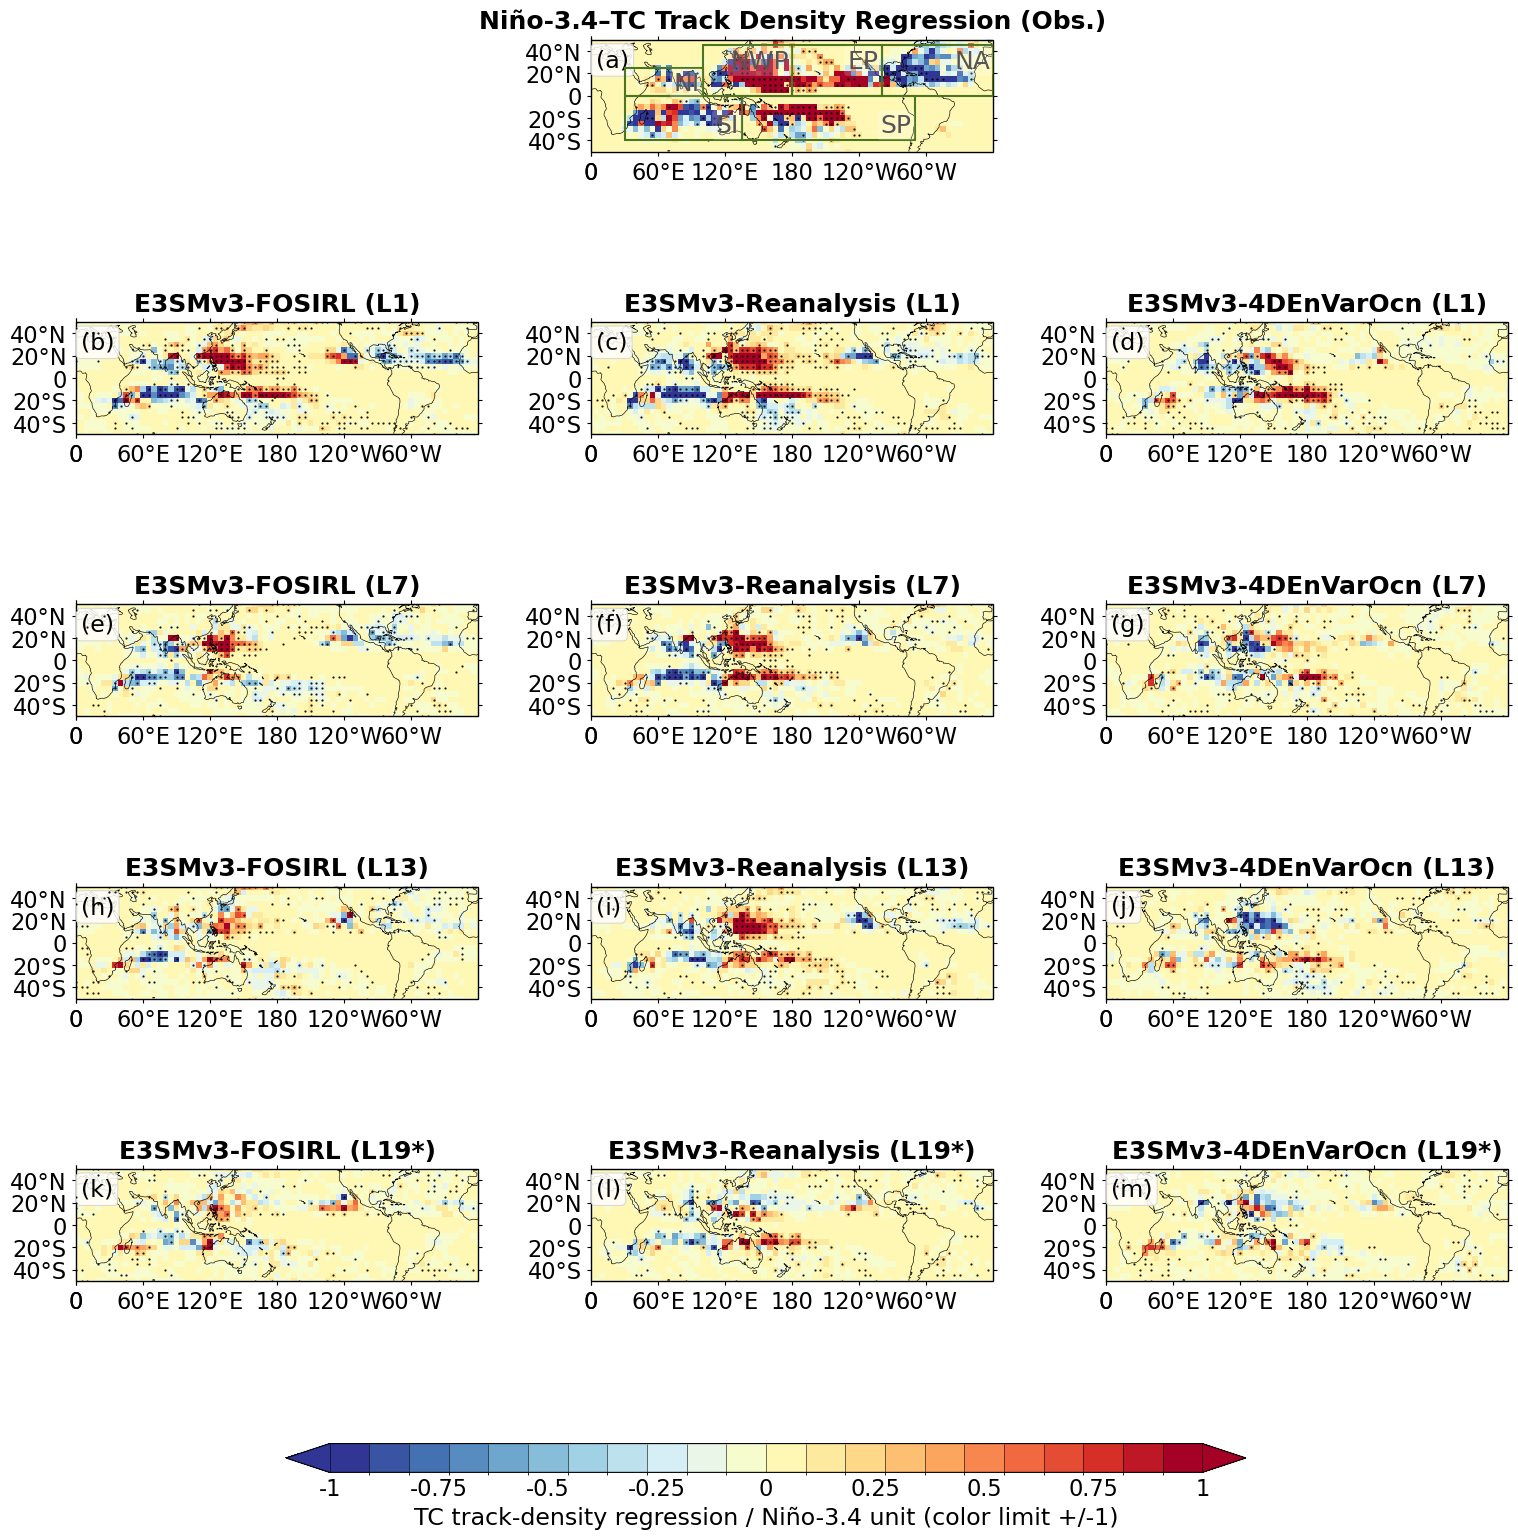

In [13]:
# =================================================================== #
#  SETUP & PLOT CONTROLS
# =================================================================== #
PLOT_LEADS_REQUESTED = globals().get("PLOT_LEADS_REQUESTED", [1, 7, 13, 19])
PLOT_SIGNIFICANT_ONLY = globals().get("PLOT_SIGNIFICANT_ONLY", False)
PLOT_SIGNIFICANCE_MARKERS = globals().get("PLOT_SIGNIFICANCE_MARKERS", True)
PLOT_MARKER_STRIDE = globals().get("PLOT_MARKER_STRIDE", 1)

# Panel title format: (L1), (L7), etc. instead of | 1-mon lead
REG_PANEL_TITLE_FMT = globals().get(
    "REG_PANEL_TITLE_FMT",
    lambda label, lead, suffix: f"{label} (L{lead}{suffix})"
)

# Regression figure layout & typography
FIGSIZE_REGRESSION = globals().get("FIGSIZE_REGRESSION", (15, 16))
FONTZ_REGRESSION = globals().get("FONTZ_REGRESSION", 11.0)
REGRESSION_SUBPLOT_ADJUST = globals().get("REGRESSION_SUBPLOT_ADJUST", dict(
    left=0.06, right=0.96, top=0.96, bottom=0.08, hspace=0.25, wspace=0.10
))
COLORBAR_AX_POSITION_REGRESSION = globals().get("COLORBAR_AX_POSITION_REGRESSION", [0.18, 0.045, 0.64, 0.018])
DPI_REGRESSION = globals().get("DPI_REGRESSION", 200)

# Figure saving and metadata
REG_METRIC = globals().get("REG_METRIC", "track_density_enso_regression")
REG_SAVE_MODE = globals().get("REG_SAVE_MODE", "tc")
REG_SAVE_TITLE = globals().get("REG_SAVE_TITLE", "E3SM TC Track Density ENSO Regression")
REG_SAVE_CAPTION = globals().get(
    "REG_SAVE_CAPTION",
    (
        "IBTrACS ENSO regression with the enabled E3SM experiments and "
        f"Niño-3.4 regression maps at leads {PLOT_LEADS_REQUESTED} "
        f"for {years}-{yeare}."
    )
)
REG_SAVE_KW = dict(
    mode=REG_SAVE_MODE,
    metric=REG_METRIC,
    title=REG_SAVE_TITLE,
    caption=REG_SAVE_CAPTION,
    dpi=DPI_REGRESSION,
)

DS_REG_BY_CASE = {}
for regression_case_key in REGRESSION_CASE_KEYS:
    regression_path = regression_diag_path(regression_case_key)
    if not regression_path.is_file():
        print(
            f"Building missing {E3SM_HINDCASTS[regression_case_key]['label']} "
            f"regression diagnostic for {years}-{yeare}."
        )
        build_regression_diagnostic(regression_case_key)
    if not regression_path.is_file():
        raise RuntimeError(f"Regression diagnostic was not created: {regression_path}")
    DS_REG_BY_CASE[regression_case_key] = _load_netcdf_fully(regression_path)
    print(
        f"Loaded {E3SM_HINDCASTS[regression_case_key]['label']} regression: "
        f"{regression_path}"
    )

# Backward-compatible alias for configuration checks below.
DS_REG = DS_REG_BY_CASE[REGRESSION_CASE_KEYS[0]]

FIGDIR = FIGURE_OUTDIR
FIGDIR.mkdir(parents=True, exist_ok=True)

available_leads_by_case = {}
for regression_case_key, regression_ds in DS_REG_BY_CASE.items():
    if "model_sample_count" in regression_ds:
        sample_by_lead = regression_ds["model_sample_count"].sum(
            ("season", "year"), skipna=True
        )
        available_leads_by_case[regression_case_key] = {
            int(lead) for lead in regression_ds.lead.values
            if float(sample_by_lead.sel(lead=lead)) > 0
        }
    else:
        available_leads_by_case[regression_case_key] = {int(lead) for lead in LEADS}
common_available_leads = set.intersection(*available_leads_by_case.values())
PLOT_LEADS = [lead for lead in PLOT_LEADS_REQUESTED if lead in common_available_leads]
if not PLOT_LEADS:
    raise ValueError("No requested model leads with positive sample count are available for plotting.")
missing_requested_leads = [lead for lead in PLOT_LEADS_REQUESTED if lead not in PLOT_LEADS]
if missing_requested_leads:
    print(f"Requested leads not available and skipped: {missing_requested_leads}")
print(f"Plotting leads available for all enabled E3SM cases: {PLOT_LEADS}")

# Global TC-season map: NH_JJASON for Northern Hemisphere basins and
# SH_DJFMAM for Southern Hemisphere basins, matching the NCL Fig. 14 layout.
obs_regression_ds = DS_REG_BY_CASE[REGRESSION_CASE_KEYS[0]]
obs_map = obs_regression_ds["obs_slope"].sum("season", skipna=True, min_count=1)
obs_sig = obs_regression_ds["obs_slope_sig"].sum("season", skipna=True, min_count=1) != 0
model_maps_by_case = {
    regression_case_key: [
        regression_ds["model_slope"].sel(lead=lead).sum("season", skipna=True, min_count=1)
        for lead in PLOT_LEADS
    ]
    for regression_case_key, regression_ds in DS_REG_BY_CASE.items()
}
model_sigs_by_case = {
    regression_case_key: [
        regression_ds["model_slope_sig"].sel(lead=lead).sum("season", skipna=True, min_count=1) != 0
        for lead in PLOT_LEADS
    ]
    for regression_case_key, regression_ds in DS_REG_BY_CASE.items()
}

if PLOT_SIGNIFICANT_ONLY:
    obs_map = obs_map.where(obs_sig)
    model_maps_by_case = {
        key: [field.where(sig) for field, sig in zip(model_maps_by_case[key], model_sigs_by_case[key])]
        for key in REGRESSION_CASE_KEYS
    }
    PLOT_SIGNIFICANCE_MARKERS = False

if COLOR_LIMIT_MODE == "yeager":
    color_limit = float(COLOR_LIMIT)
else:
    all_model_maps = [
        field for key in REGRESSION_CASE_KEYS for field in model_maps_by_case[key]
    ]
    model_values = np.concatenate([
        np.ravel(np.asarray(field.values, dtype=float))
        for field in all_model_maps
        if np.isfinite(field.values).any()
    ])
    model_values = np.abs(model_values[np.isfinite(model_values)])
    if model_values.size:
        color_limit = max(COLOR_LIMIT_MIN, float(np.nanpercentile(model_values, COLOR_LIMIT_PERCENTILE)))
        color_limit = np.ceil(color_limit * 10.0) / 10.0
    else:
        color_limit = float(COLOR_LIMIT)
LEVELS = np.linspace(-color_limit, color_limit, N_COLOR_INTERVALS + 1)
TICKS = np.linspace(-color_limit, color_limit, N_COLORBAR_TICKS)
cmap = plt.get_cmap(COLORMAP_NAME).copy()
cmap.set_bad((1, 1, 1, 0))

n_panels = 1 + len(REGRESSION_CASE_KEYS) * len(PLOT_LEADS)
grid_nrows = 1 + len(PLOT_LEADS)
grid_ncols = len(REGRESSION_CASE_KEYS)
obs_grid_slot = (0, grid_ncols // 2)
fig = plt.figure(figsize=FIGSIZE_REGRESSION)
gs = fig.add_gridspec(grid_nrows, grid_ncols)

axes = [
    fig.add_subplot(
        gs[obs_grid_slot],
        projection=ccrs.PlateCarree(central_longitude=CENTRAL_LONGITUDE_REGRESSION),
    )
]
fields = [obs_map]
sigs = [obs_sig]
titles = ["Niño-3.4–TC Track Density Regression (Obs.)"]
for lead_index, lead in enumerate(PLOT_LEADS):
    row = lead_index + 1
    for case_col, regression_case_key in enumerate(REGRESSION_CASE_KEYS):
        axes.append(
            fig.add_subplot(
                gs[row, case_col],
                projection=ccrs.PlateCarree(central_longitude=CENTRAL_LONGITUDE_REGRESSION),
            )
        )
        fields.append(model_maps_by_case[regression_case_key][lead_index])
        sigs.append(model_sigs_by_case[regression_case_key][lead_index])
        lead_suffix = "*" if lead == 19 else ""
        titles.append(
            REG_PANEL_TITLE_FMT(
                E3SM_HINDCASTS[regression_case_key]["label"],
                lead,
                lead_suffix,
            )
        )

panel_labels = [f"({chr(97 + i)})" for i in range(n_panels)]
im = None
for idx, (ax, field, sig, title, panel_label) in enumerate(zip(axes, fields, sigs, titles, panel_labels)):
    im = _plot_regression_panel(
        ax, field, sig, title, panel_label,
        show_basin_boxes=(idx == 0),
    )

cbar_ax = fig.add_axes(COLORBAR_AX_POSITION_REGRESSION)
cbar = fig.colorbar(
    im, cax=cbar_ax, orientation="horizontal",
    ticks=TICKS, extend="both", drawedges=True,
)
cbar.ax.set_xticklabels([f"{tick:.2g}" for tick in TICKS])
cbar.ax.tick_params(labelsize=COLORBAR_TICK_FONTSIZE_REGRESSION, length=0)
cbar.set_label(f"TC track-density regression / Niño-3.4 unit (color limit +/-{color_limit:g})", fontsize=COLORBAR_LABEL_FONTSIZE_REGRESSION)
fig.subplots_adjust(**REGRESSION_SUBPLOT_ADJUST)
FIG_REG_OUT = FIGDIR / figure_filename(
    "tc_track_density", "enso_regression", "enabled_e3sm", years, yeare
)
mov.save_figure(fig, FIG_REG_OUT, **REG_SAVE_KW)
print(f"Saved ENSO-TC regression plot: {FIG_REG_OUT}")
plt.show()


## 10. Multi-E3SM hindcast lead-time statistics

Load every configured E3SM diagnostic cache and tabulate global annual TC track-point density and detected storm counts across lead time. Each lead uses the intersection of valid verification years across all available hindcasts, with IBTrACS sampled on that same cohort. The table reports model values, observed references, biases, and model/observation ratios. Exact-period caches were ensured automatically before the comparison figures.


In [14]:
# ============================================================
# Multi-E3SM lead-time statistics from cached diagnostics
# ============================================================
import pandas as pd
from IPython.display import display

comparison_cfg = MULTI_E3SM_STATISTICS_CONFIG
comparison_datasets = {}
missing_comparison_caches = {}

for case_key in comparison_cfg["case_keys"]:
    path = hindcast_diag_path(case_key)
    if path.is_file():
        dataset = _load_netcdf_fully(path)
    else:
        missing_comparison_caches[case_key] = path
        continue

    required_vars = {
        "tc_track_density_count", "tc_basin_track_density_count",
        "tc_storm_count", "sample_count"
    }
    missing_vars = required_vars.difference(dataset.data_vars)
    if missing_vars:
        print(f"Skipping {case_key}: cache lacks {sorted(missing_vars)}")
        continue
    comparison_datasets[case_key] = dataset

for case_key, path in missing_comparison_caches.items():
    print(
        f"Comparison cache missing for {case_key}: {path}. "
        f"Use TC_DIAGNOSTIC_MODE='auto' to build it or 'rebuild' to replace it."
    )

if not comparison_datasets:
    raise FileNotFoundError("No enabled E3SM hindcast diagnostic caches are available.")

obs_source = next(
    (dataset for dataset in comparison_datasets.values() if "obs_track_density_count" in dataset),
    None,
)
if obs_source is None:
    raise ValueError("No loaded diagnostic contains the IBTrACS companion variables. Run Section 8 first.")
if "obs_basin_track_density_count" not in obs_source:
    raise ValueError(
        "The IBTrACS companion cache lacks obs_basin_track_density_count. "
        "Rerun Section 8."
    )

required_seasons = comparison_cfg["required_seasons"]
common_leads = None
for dataset in comparison_datasets.values():
    leads_here = set(map(int, dataset.lead.values))
    common_leads = leads_here if common_leads is None else common_leads.intersection(leads_here)
common_leads = np.asarray(sorted(common_leads), dtype=int)
if common_leads.size == 0:
    raise ValueError("The available E3SM diagnostics have no common lead coordinates.")

comparison_rows = []
basin_comparison_rows = []
for lead in common_leads:
    valid_year_sets = []
    for dataset in comparison_datasets.values():
        samples = dataset["sample_count"].sel(lead=lead, season=required_seasons)
        valid = (samples > 0).all("season")
        valid_year_sets.append(set(map(int, valid.year.values[valid.values])))

    obs_samples = obs_source["obs_sample_count"].sel(season=required_seasons)
    obs_valid = (obs_samples > 0).all("season")
    valid_year_sets.append(set(map(int, obs_valid.year.values[obs_valid.values])))
    common_years = np.asarray(sorted(set.intersection(*valid_year_sets)), dtype=int)
    if common_years.size == 0:
        print(f"Skipping lead {lead}: no common valid verification years.")
        continue

    obs_sample = (
        obs_source["obs_sample_count"]
        .sel(year=common_years, season=required_seasons)
        .min("season")
    )
    obs_track = (
        obs_source["obs_track_density_count"]
        .sel(year=common_years, season=required_seasons)
        .sum("season", skipna=True, min_count=1)
        / obs_sample.where(obs_sample > 0)
    ).sum(("lat", "lon"), skipna=True).mean("year", skipna=True)
    obs_storm = (
        obs_source["obs_storm_count"]
        .sel(year=common_years, season=required_seasons)
        .sum("season", skipna=True, min_count=1)
        / obs_sample.where(obs_sample > 0)
    ).mean("year", skipna=True)
    obs_basin_track = (
        obs_source["obs_basin_track_density_count"]
        .sel(year=common_years, season=required_seasons)
        .sum("season", skipna=True, min_count=1)
        / obs_sample.where(obs_sample > 0)
    ).mean("year", skipna=True)

    for case_key, dataset in comparison_datasets.items():
        model_sample = (
            dataset["sample_count"]
            .sel(lead=lead, year=common_years, season=required_seasons)
            .min("season")
        )
        model_track = (
            dataset["tc_track_density_count"]
            .sel(lead=lead, year=common_years, season=required_seasons)
            .sum("season", skipna=True, min_count=1)
            / model_sample.where(model_sample > 0)
        ).sum(("lat", "lon"), skipna=True).mean("year", skipna=True)
        model_storm = (
            dataset["tc_storm_count"]
            .sel(lead=lead, year=common_years, season=required_seasons)
            .sum("season", skipna=True, min_count=1)
            / model_sample.where(model_sample > 0)
        ).mean("year", skipna=True)
        model_basin_track = (
            dataset["tc_basin_track_density_count"]
            .sel(lead=lead, year=common_years, season=required_seasons)
            .sum("season", skipna=True, min_count=1)
            / model_sample.where(model_sample > 0)
        ).mean("year", skipna=True)
        comparison_rows.append({
            "case": case_key,
            "lead": int(lead),
            "n_years": int(common_years.size),
            "year_start": int(common_years.min()),
            "year_end": int(common_years.max()),
            "track_density_total": float(model_track),
            "storm_count": float(model_storm),
            "obs_track_density_total": float(obs_track),
            "obs_storm_count": float(obs_storm),
        })
        common_basins = np.intersect1d(
            model_basin_track.basin.values, obs_basin_track.basin.values
        )
        for basin in common_basins:
            basin_comparison_rows.append({
                "case": case_key,
                "lead": int(lead),
                "basin": str(basin),
                "n_years": int(common_years.size),
                "year_start": int(common_years.min()),
                "year_end": int(common_years.max()),
                "track_density_total": float(model_basin_track.sel(basin=basin)),
                "obs_track_density_total": float(obs_basin_track.sel(basin=basin)),
            })

comparison_table = pd.DataFrame(comparison_rows)
if comparison_table.empty:
    raise ValueError("No common-cohort lead metrics could be computed.")
comparison_table["model"] = comparison_table["case"].map(
    {key: spec["label"] for key, spec in E3SM_HINDCASTS.items()}
)
comparison_table["track_density_bias"] = (
    comparison_table["track_density_total"]
    - comparison_table["obs_track_density_total"]
)
comparison_table["track_density_ratio"] = (
    comparison_table["track_density_total"]
    / comparison_table["obs_track_density_total"].replace(0, np.nan)
)
comparison_table["storm_count_bias"] = (
    comparison_table["storm_count"] - comparison_table["obs_storm_count"]
)
comparison_table["storm_count_ratio"] = (
    comparison_table["storm_count"]
    / comparison_table["obs_storm_count"].replace(0, np.nan)
)

table_columns = [
    "n_years", "year_start", "year_end",
    "track_density_total", "obs_track_density_total",
    "track_density_bias", "track_density_ratio",
    "storm_count", "obs_storm_count",
    "storm_count_bias", "storm_count_ratio",
]
comparison_table = (
    comparison_table
    .set_index(["lead", "model"])
    .sort_index()
    [table_columns]
)
comparison_table_display = comparison_table.copy()
float_columns = comparison_table_display.select_dtypes(include=["floating"]).columns
comparison_table_display[float_columns] = comparison_table_display[float_columns].round(3)
print(
    "Multi-E3SM global TC statistics on lead-specific common verification cohorts\n"
    "Bias = model - IBTrACS; ratio = model / IBTrACS."
)
display(comparison_table_display)

basin_table = pd.DataFrame(basin_comparison_rows)
if basin_table.empty:
    raise ValueError("No common-cohort basin statistics could be computed.")
basin_names = {name: spec["long_name"] for name, spec in BASIN_DEFS.items()}
basin_order = list(basin_names)
basin_table["model"] = basin_table["case"].map(
    {key: spec["label"] for key, spec in E3SM_HINDCASTS.items()}
)
basin_table["basin_name"] = basin_table["basin"].map(basin_names)
basin_table["track_density_bias"] = (
    basin_table["track_density_total"]
    - basin_table["obs_track_density_total"]
)
basin_table["track_density_ratio"] = (
    basin_table["track_density_total"]
    / basin_table["obs_track_density_total"].replace(0, np.nan)
)
basin_table["basin"] = pd.Categorical(
    basin_table["basin"], categories=basin_order, ordered=True
)
basin_table = (
    basin_table
    .sort_values(["lead", "basin", "model"])
    .set_index(["lead", "basin", "model"])
    [[
        "basin_name", "n_years", "year_start", "year_end",
        "track_density_total", "obs_track_density_total",
        "track_density_bias", "track_density_ratio",
    ]]
)
basin_table_display = basin_table.copy()
basin_float_columns = basin_table_display.select_dtypes(include=["floating"]).columns
basin_table_display[basin_float_columns] = (
    basin_table_display[basin_float_columns].round(3)
)
print(
    "\nBasin-integrated TC track-density statistics\n"
    "Bias = model - IBTrACS; ratio = model / IBTrACS."
)
display(basin_table_display)

start_yr = int(comparison_table["year_start"].min())
end_yr = int(comparison_table["year_end"].max())
comparison_table_path = TABLE_OUTDIR / f"tc_multimodel_global_stats_{start_yr}_{end_yr}.csv"
comparison_table.to_csv(comparison_table_path)
print(f"Saved global comparison table: {comparison_table_path}")

basin_table_path = TABLE_OUTDIR / f"tc_basin_stats_{start_yr}_{end_yr}.csv"
basin_table.to_csv(basin_table_path)
print(f"Saved basin comparison table: {basin_table_path}")


Skipping lead 4: no common valid verification years.
Skipping lead 10: no common valid verification years.
Skipping lead 16: no common valid verification years.
Multi-E3SM global TC statistics on lead-specific common verification cohorts
Bias = model - IBTrACS; ratio = model / IBTrACS.


n_years  year_start  year_end  track_density_total  \
lead model                                                                   
1    E3SMv3-4DEnVarOcn       32        1980      2011              951.475   
     E3SMv3-FOSIRL           32        1980      2011              951.122   
     E3SMv3-Reanalysis       32        1980      2011              979.122   
7    E3SMv3-4DEnVarOcn       31        1981      2011              935.255   
     E3SMv3-FOSIRL           31        1981      2011              844.932   
     E3SMv3-Reanalysis       31        1981      2011              854.706   
13   E3SMv3-4DEnVarOcn       31        1981      2011              917.045   
     E3SMv3-FOSIRL           31        1981      2011              961.535   
     E3SMv3-Reanalysis       31        1981      2011              876.384   
19   E3SMv3-4DEnVarOcn       30        1982      2011              843.720   
     E3SMv3-FOSIRL           30        1982      2011              820.103   
     E3SMv3-Reanalysis       30        1982      2011              798.030   

                        obs_track_density_total  track_density_bias  \
lead model                                                            
1    E3SMv3-4DEnVarOcn                 1737.500            -786.025   
     E3SMv3-FOSIRL                     1737.500            -786.378   
     E3SMv3-Reanalysis                 1737.500            -758.378   
7    E3SMv3-4DEnVarOcn                 1746.677            -811.423   
     E3SMv3-FOSIRL                     1746.677            -901.745   
     E3SMv3-Reanalysis                 1746.677            -891.971   
13   E3SMv3-4DEnVarOcn                 1746.677            -829.632   
     E3SMv3-FOSIRL                     1746.677            -785.142   
     E3SMv3-Reanalysis                 1746.677            -870.294   
19   E3SMv3-4DEnVarOcn                 1747.867            -904.147   
     E3SMv3-FOSIRL                     1747.867            -927.763   
     E3SMv3-Reanalysis                 1747.867            -949.837   

                        track_density_ratio  storm_count  obs_storm_count  \
lead model                                                                  
1    E3SMv3-4DEnVarOcn                0.548       42.231           89.750   
     E3SMv3-FOSIRL                    0.547       44.012           89.750   
     E3SMv3-Reanalysis                0.564       43.916           89.750   
7    E3SMv3-4DEnVarOcn                0.535       41.794           89.935   
     E3SMv3-FOSIRL                    0.484       40.813           89.935   
     E3SMv3-Reanalysis                0.489       40.135           89.935   
13   E3SMv3-4DEnVarOcn                0.525       41.000           89.935   
     E3SMv3-FOSIRL                    0.550       44.813           89.935   
     E3SMv3-Reanalysis                0.502       40.471           89.935   
19   E3SMv3-4DEnVarOcn                0.483       37.473           89.833   
     E3SMv3-FOSIRL                    0.469       38.130           89.833   
     E3SMv3-Reanalysis                0.457       36.230           89.833   

                        storm_count_bias  storm_count_ratio  
lead model                                                   
1    E3SMv3-4DEnVarOcn           -47.519              0.471  
     E3SMv3-FOSIRL               -45.738              0.490  
     E3SMv3-Reanalysis           -45.834              0.489  
7    E3SMv3-4DEnVarOcn           -48.142              0.465  
     E3SMv3-FOSIRL               -49.123              0.454  
     E3SMv3-Reanalysis           -49.800              0.446  
13   E3SMv3-4DEnVarOcn           -48.935              0.456  
     E3SMv3-FOSIRL               -45.123              0.498  
     E3SMv3-Reanalysis           -49.465              0.450  
19   E3SMv3-4DEnVarOcn           -52.360              0.417  
     E3SMv3-FOSIRL               -51.703              0.424  
     E3SMv3-Reanalysis           -53.603           


Basin-integrated TC track-density statistics
Bias = model - IBTrACS; ratio = model / IBTrACS.


basin_name  n_years  year_start  \
lead basin model                                                          
1    NWP   E3SMv3-4DEnVarOcn  Northwestern Pacific       32        1980   
           E3SMv3-FOSIRL      Northwestern Pacific       32        1980   
           E3SMv3-Reanalysis  Northwestern Pacific       32        1980   
     NA    E3SMv3-4DEnVarOcn        North Atlantic       32        1980   
           E3SMv3-FOSIRL            North Atlantic       32        1980   
...                                            ...      ...         ...   
19   SI    E3SMv3-FOSIRL        South Indian Ocean       30        1982   
           E3SMv3-Reanalysis    South Indian Ocean       30        1982   
     SP    E3SMv3-4DEnVarOcn   South Pacific Ocean       30        1982   
           E3SMv3-FOSIRL       South Pacific Ocean       30        1982   
           E3SMv3-Reanalysis   South Pacific Ocean       30        1982   

                              year_end  track_density_total  \
lead basin model                                              
1    NWP   E3SMv3-4DEnVarOcn      2011              308.653   
           E3SMv3-FOSIRL          2011              174.913   
           E3SMv3-Reanalysis      2011              228.481   
     NA    E3SMv3-4DEnVarOcn      2011               16.087   
           E3SMv3-FOSIRL          2011               55.091   
...                                ...                  ...   
19   SI    E3SMv3-FOSIRL          2011              199.917   
           E3SMv3-Reanalysis      2011              181.400   
     SP    E3SMv3-4DEnVarOcn      2011              141.153   
           E3SMv3-FOSIRL          2011               74.913   
           E3SMv3-Reanalysis      2011               88.827   

                              obs_track_density_total  track_density_bias  \
lead basin model                                                            
1    NWP   E3SMv3-4DEnVarOcn                  489.781            -181.128   
           E3SMv3-FOSIRL                      489.781            -314.869   
           E3SMv3-Reanalysis                  489.781            -261.300   
     NA    E3SMv3-4DEnVarOcn                  237.312            -221.225   
           E3SMv3-FOSIRL                      237.312            -182.222   
...                                               ...                 ...   
19   SI    E3SMv3-FOSIRL                      298.800             -98.883   
           E3SMv3-Reanalysis                  298.800            -117.400   
     SP    E3SMv3-4DEnVarOcn                  185.167             -44.013   
           E3SMv3-FOSIRL                      185.167            -110.253   
           E3SMv3-Reanalysis                  185.167             -96.340   

                              track_density_ratio  
lead basin model                                   
1    NWP   E3SMv3-4DEnVarOcn                0.630  
           E3SMv3-FOSIRL                    0.357  
           E3SMv3-Reanalysis                0.466  
     NA    E3SMv3-4DEnVarOcn                0.068  
           E3SMv3-FOSIRL                    0.232  
...                                           ...  
19   SI    E3SMv3-FOSIRL                    0.669  
           E3SMv3-Reanalysis                0.607  
     SP    E3SMv3-4DEnVarOcn                0.762  
           E3SMv3-FOSIRL                    0.405  
           E3SMv3-Reanalysis                0.480  

[72 rows x 8 columns]

Saved global comparison table: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/tropical_cyclones/tables/tc_multimodel_global_stats_1980_2011.csv
Saved basin comparison table: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/tropical_cyclones/tables/tc_basin_stats_1980_2011.csv
